In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="kMxbR8scxz4XULrpzbZu")
project = rf.workspace("garretts-workspace").project("dog-poop-health-id-2")
version = project.version(2)
dataset = version.download("multiclass")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 99.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Dog-Poop-Health-ID-2-2 in multiclass:: 100%|██████████| 3959/3959 [00:00<00:00, 3975.93it/s]


In [2]:
import os

# Voir la structure du dataset
dataset_path = '/content/Dog-Poop-Health-ID-2-2'
print(os.listdir(dataset_path))

['README.roboflow.txt', 'test', 'train', 'valid', 'README.dataset.txt']


In [3]:
# 1. CONFIGURATION & IMPORTS
%matplotlib inline
import os
import shutil
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
import cv2

print("Environnement configuré pour le Deep Learning & RAG")
print(f"TensorFlow version: {tf.__version__}")

Environnement configuré pour le Deep Learning & RAG
TensorFlow version: 2.20.0


In [4]:
# ════════════════════════════════════════════
# 2. LOADING DATA
# ════════════════════════════════════════════

import os
import pandas as pd
import numpy as np

# ── Chemins ──
DATASET_PATH = '/content/Dog-Poop-Health-ID-2-2'
TRAIN_PATH   = os.path.join(DATASET_PATH, "train")
VALID_PATH   = os.path.join(DATASET_PATH, "valid")
TEST_PATH    = os.path.join(DATASET_PATH, "test")

# ── Vérification structure ──
print("Structure du dataset :")
for split in ["train", "valid", "test"]:
    path  = os.path.join(DATASET_PATH, split)
    files = os.listdir(path)
    imgs  = [f for f in files if f.endswith(('.jpg', '.png'))]
    print(f"   {split:10s} : {len(imgs)} images")

# ── Chargement CSV ──
df_train = pd.read_csv(os.path.join(TRAIN_PATH, "_classes.csv"))
df_valid = pd.read_csv(os.path.join(VALID_PATH, "_classes.csv"))
df_test  = pd.read_csv(os.path.join(TEST_PATH,  "_classes.csv"))

CLASSES = ['Blood', 'Diarrhoea', 'LackOfWater', 'Normal', 'SoftPoop', 'Worms']

print(f"\nCSV charges :")
print(f"   Train : {len(df_train)} lignes")
print(f"   Valid : {len(df_valid)} lignes")
print(f"   Test  : {len(df_test)} lignes")
print(f"\nColonnes : {df_train.columns.tolist()}")
print(f"\nApercu :")
print(df_train.head())
print(df_train.sample(5))

Structure du dataset :
   train      : 3451 images
   valid      : 334 images
   test       : 166 images

CSV charges :
   Train : 3451 lignes
   Valid : 334 lignes
   Test  : 166 lignes

Colonnes : ['filename', 'Blood', 'Diarrhoea', 'LackOfWater', 'Normal', 'SoftPoop', 'Worms']

Apercu :
                                            filename  Blood  Diarrhoea  \
0  Diarrhoea_165_jpg.rf.a1d412ffc5a50898961b4a3ea...      0          1   
1  Diarrhoea_126_jpg.rf.768454721160869c2c5fc637b...      0          1   
2  Diarrhoea_128_jpg.rf.a333e9b1d9b1390b98a6b92ee...      0          1   
3  Diarrhoea_161_jpg.rf.a01d15364c650181a2c45717d...      0          1   
4  Diarrhoea_133_jpg.rf.2fa272c304c6265d0a2032ae0...      0          1   

   LackOfWater  Normal  SoftPoop  Worms  
0            0       0         0      0  
1            0       0         0      0  
2            0       0         0      0  
3            0       0         0      0  
4            0       0         0      0  
             

   A. DESCRIPTION DU DATASET

Shape Train : (3451, 7)
Shape Valid : (334, 7)
Shape Test  : (166, 7)

Info Train :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3451 entries, 0 to 3450
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   filename     3451 non-null   object
 1   Blood        3451 non-null   int64 
 2   Diarrhoea    3451 non-null   int64 
 3   LackOfWater  3451 non-null   int64 
 4   Normal       3451 non-null   int64 
 5   SoftPoop     3451 non-null   int64 
 6   Worms        3451 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 188.9+ KB

Statistiques descriptives :
             Blood    Diarrhoea  LackOfWater       Normal     SoftPoop  \
count  3451.000000  3451.000000  3451.000000  3451.000000  3451.000000   
mean      0.011011     0.197334     0.299044     0.303101     0.200522   
std       0.104371     0.398044     0.457905     0.459665     0.400449   
min       0.000000     0.000000   

<Figure size 640x480 with 0 Axes>

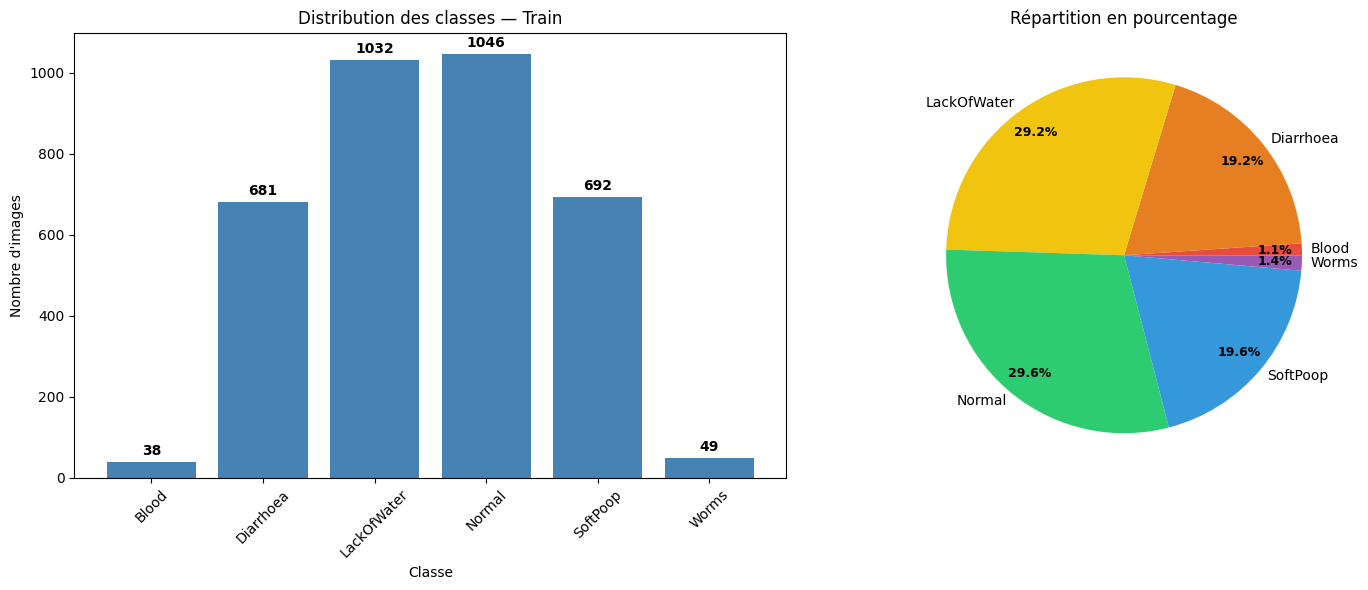


   C. HEATMAP CO-OCCURRENCES MULTI-LABEL


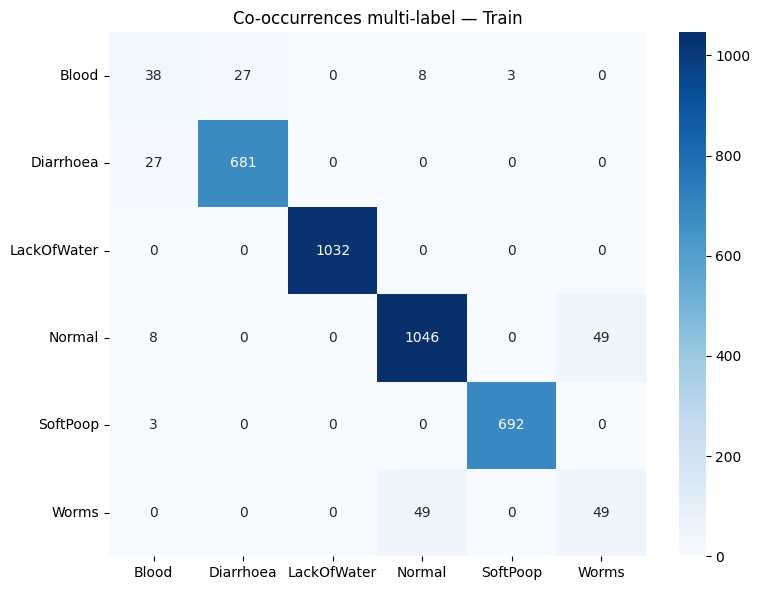


   D. STATISTIQUES MULTI-LABEL

Images single-label : 3364
Images multi-label  : 87
Images sans label   : 0


In [5]:
# ════════════════════════════════════════════
# 3. DATA DESCRIPTION & VISUALIZATION
# ════════════════════════════════════════════

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns

# Force le bon backend matplotlib
%matplotlib inline

# ── A. Dataset Description ──
print("=" * 50)
print("   A. DESCRIPTION DU DATASET")
print("=" * 50)

print(f"\nShape Train : {df_train.shape}")
print(f"Shape Valid : {df_valid.shape}")
print(f"Shape Test  : {df_test.shape}")

print(f"\nInfo Train :")
df_train.info()

print(f"\nStatistiques descriptives :")
print(df_train[CLASSES].describe())

print(f"\nValeurs manquantes :")
print(df_train.isnull().sum())

print(f"\nDoublons (noms) : {df_train.duplicated().sum()}")

# ── B. Distribution des classes ──
print("\n" + "=" * 50)
print("   B. DISTRIBUTION DES CLASSES")
print("=" * 50)

counts = df_train[CLASSES].sum().values
print("\nNombre d'images par classe (Train) :")
for cls, cnt in zip(CLASSES, counts):
    print(f"   {cls:15s} : {int(cnt)}")
print(f"\nRatio desequilibre : {int(max(counts))/int(min(counts)):.1f}x")
plt.tight_layout()
plt.show()

# Création des graphiques
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
bars = axes[0].bar(CLASSES, counts, color='steelblue')
axes[0].set_title('Distribution des classes — Train')
axes[0].set_ylabel("Nombre d'images")
axes[0].set_xlabel("Classe")
axes[0].tick_params(axis='x', rotation=45)   # Rotation des labels pour meilleure lisibilité

for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10,
                 str(int(cnt)),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart (amélioré)
wedges, texts, autotexts = axes[1].pie(
    counts,
    labels=CLASSES,
    autopct='%1.1f%%',
    colors=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6'],
    textprops={'fontsize': 10},
    pctdistance=0.85,
    labeldistance=1.05
)

# Amélioration des labels du pie chart
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')

axes[1].set_title('Répartition en pourcentage')

plt.tight_layout()
plt.show()

# ── C. Heatmap co-occurrences ──
print("\n" + "=" * 50)
print("   C. HEATMAP CO-OCCURRENCES MULTI-LABEL")
print("=" * 50)

cooccurrence = df_train[CLASSES].T.dot(df_train[CLASSES])
plt.figure(figsize=(8, 6))
sns.heatmap(cooccurrence, annot=True, fmt='d',
            cmap='Blues', xticklabels=CLASSES,
            yticklabels=CLASSES)
plt.title('Co-occurrences multi-label — Train')
plt.tight_layout()
plt.show()

# ── D. Stats multi-label ──
print("\n" + "=" * 50)
print("   D. STATISTIQUES MULTI-LABEL")
print("=" * 50)

single = int((df_train[CLASSES].sum(axis=1) == 1).sum())
multi  = int((df_train[CLASSES].sum(axis=1) >  1).sum())
zero   = int((df_train[CLASSES].sum(axis=1) == 0).sum())

print(f"\nImages single-label : {single}")
print(f"Images multi-label  : {multi}")
print(f"Images sans label   : {zero}")

   B. DETECTION DOUBLONS REELS
Doublons réels trouvés : 56
Images uniques gardées : 3395

   C. DETECTION IMAGES CORROMPUES
Images corrompues supprimées : 0

   D. BALANCING — OVERSAMPLING
Augmentation Blood           : 37 -> 1027
Augmentation Diarrhoea       : 672 -> 1027
Augmentation LackOfWater     : 1014 -> 1027
Augmentation SoftPoop        : 682 -> 1027
Augmentation Worms           : 48 -> 1027


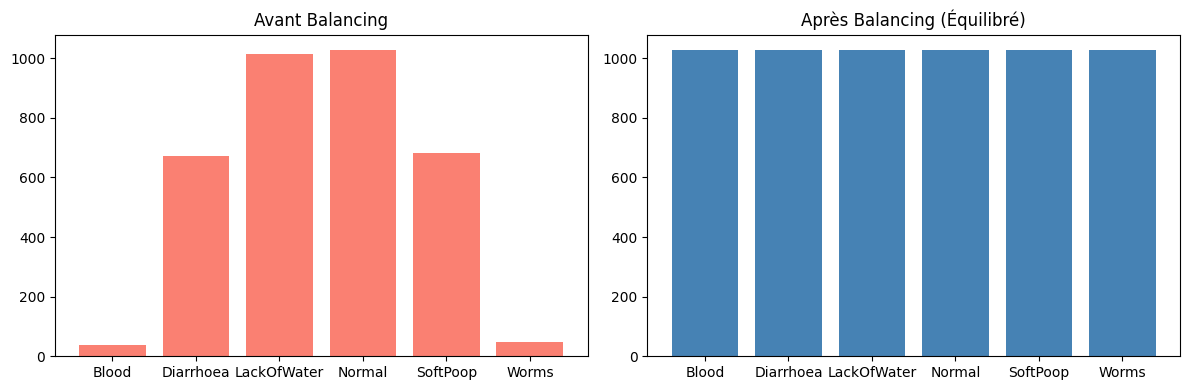


Nettoyage et Balancing terminés. Total images : 6077


In [6]:
# ════════════════════════════════════════════
# 4. DATA CLEANING + BALANCING
# ════════════════════════════════════════════

import hashlib
import shutil
import glob
import os
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- A. Sécurité : Nettoyage des anciennes augmentations ---
# Cela évite de dupliquer à l'infini si on relance la cellule
old_aug_files = glob.glob(os.path.join(TRAIN_PATH, "aug_*"))
if len(old_aug_files) > 0:
    for f in old_aug_files:
        os.remove(f)
    print(f" Nettoyage préventif : {len(old_aug_files)} anciennes copies supprimées.\n")

# --- B. Détection doublons réels (hash MD5) ---
print("=" * 50)
print("   B. DETECTION DOUBLONS REELS")
print("=" * 50)

hashes_clean = {}
to_keep = []
duplicates = []

for fname in df_train['filename']:
    fpath = os.path.join(TRAIN_PATH, fname)
    try:
        with open(fpath, 'rb') as f:
            h = hashlib.md5(f.read()).hexdigest()
        if h not in hashes_clean:
            hashes_clean[h] = fname
            to_keep.append(fname)
        else:
            duplicates.append(fname)
    except:
        pass

print(f"Doublons réels trouvés : {len(duplicates)}")
print(f"Images uniques gardées : {len(to_keep)}")

df_train_clean = df_train[df_train['filename'].isin(to_keep)].reset_index(drop=True)

# --- C. Détection images corrompues ---
print("\n" + "=" * 50)
print("   C. DETECTION IMAGES CORROMPUES")
print("=" * 50)

corrupted = []
for fname in df_train_clean['filename']:
    fpath = os.path.join(TRAIN_PATH, fname)
    try:
        img = Image.open(fpath)
        img.verify()
    except:
        corrupted.append(fname)

df_train_clean = df_train_clean[~df_train_clean['filename'].isin(corrupted)].reset_index(drop=True)
print(f"Images corrompues supprimées : {len(corrupted)}")

# --- D. Balancing — Oversampling Complet ---
print("\n" + "=" * 50)
print("   D. BALANCING — OVERSAMPLING")
print("=" * 50)

counts_before = df_train_clean[CLASSES].sum().values
TARGET = int(max(counts_before))
df_augmented = df_train_clean.copy()
added_per_class = {cls: 0 for cls in CLASSES}

for cls in CLASSES:
    cls_df = df_train_clean[df_train_clean[cls] == 1]
    current = len(cls_df)
    needed = TARGET - current

    if needed > 0:
        print(f"Augmentation {cls:15s} : {current} -> {TARGET}")
        extra = cls_df.sample(n=needed, replace=True, random_state=42)

        new_rows = []
        for i, (idx, row) in enumerate(extra.iterrows()):
            old_name = row['filename']
            new_name = f"aug_{cls}_{i}_{old_name}"
            shutil.copy(os.path.join(TRAIN_PATH, old_name),
                        os.path.join(TRAIN_PATH, new_name))
            new_row = row.copy()
            new_row['filename'] = new_name
            new_rows.append(new_row)

        df_augmented = pd.concat([df_augmented, pd.DataFrame(new_rows)], ignore_index=True)
        added_per_class[cls] = needed

df_augmented['label'] = df_augmented[CLASSES].idxmax(axis=1)

# --- F. Visualisation ---
counts_after = np.array([
    int(df_train_clean[cls].sum()) + added_per_class[cls] for cls in CLASSES
])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(CLASSES, counts_before, color='salmon')
ax[0].set_title("Avant Balancing")
ax[1].bar(CLASSES, counts_after, color='steelblue')
ax[1].set_title("Après Balancing (Équilibré)")
plt.tight_layout()
plt.show()

df_augmented.to_csv(os.path.join(TRAIN_PATH, '_classes_clean.csv'), index=False)
print(f"\nNettoyage et Balancing terminés. Total images : {len(df_augmented)}")

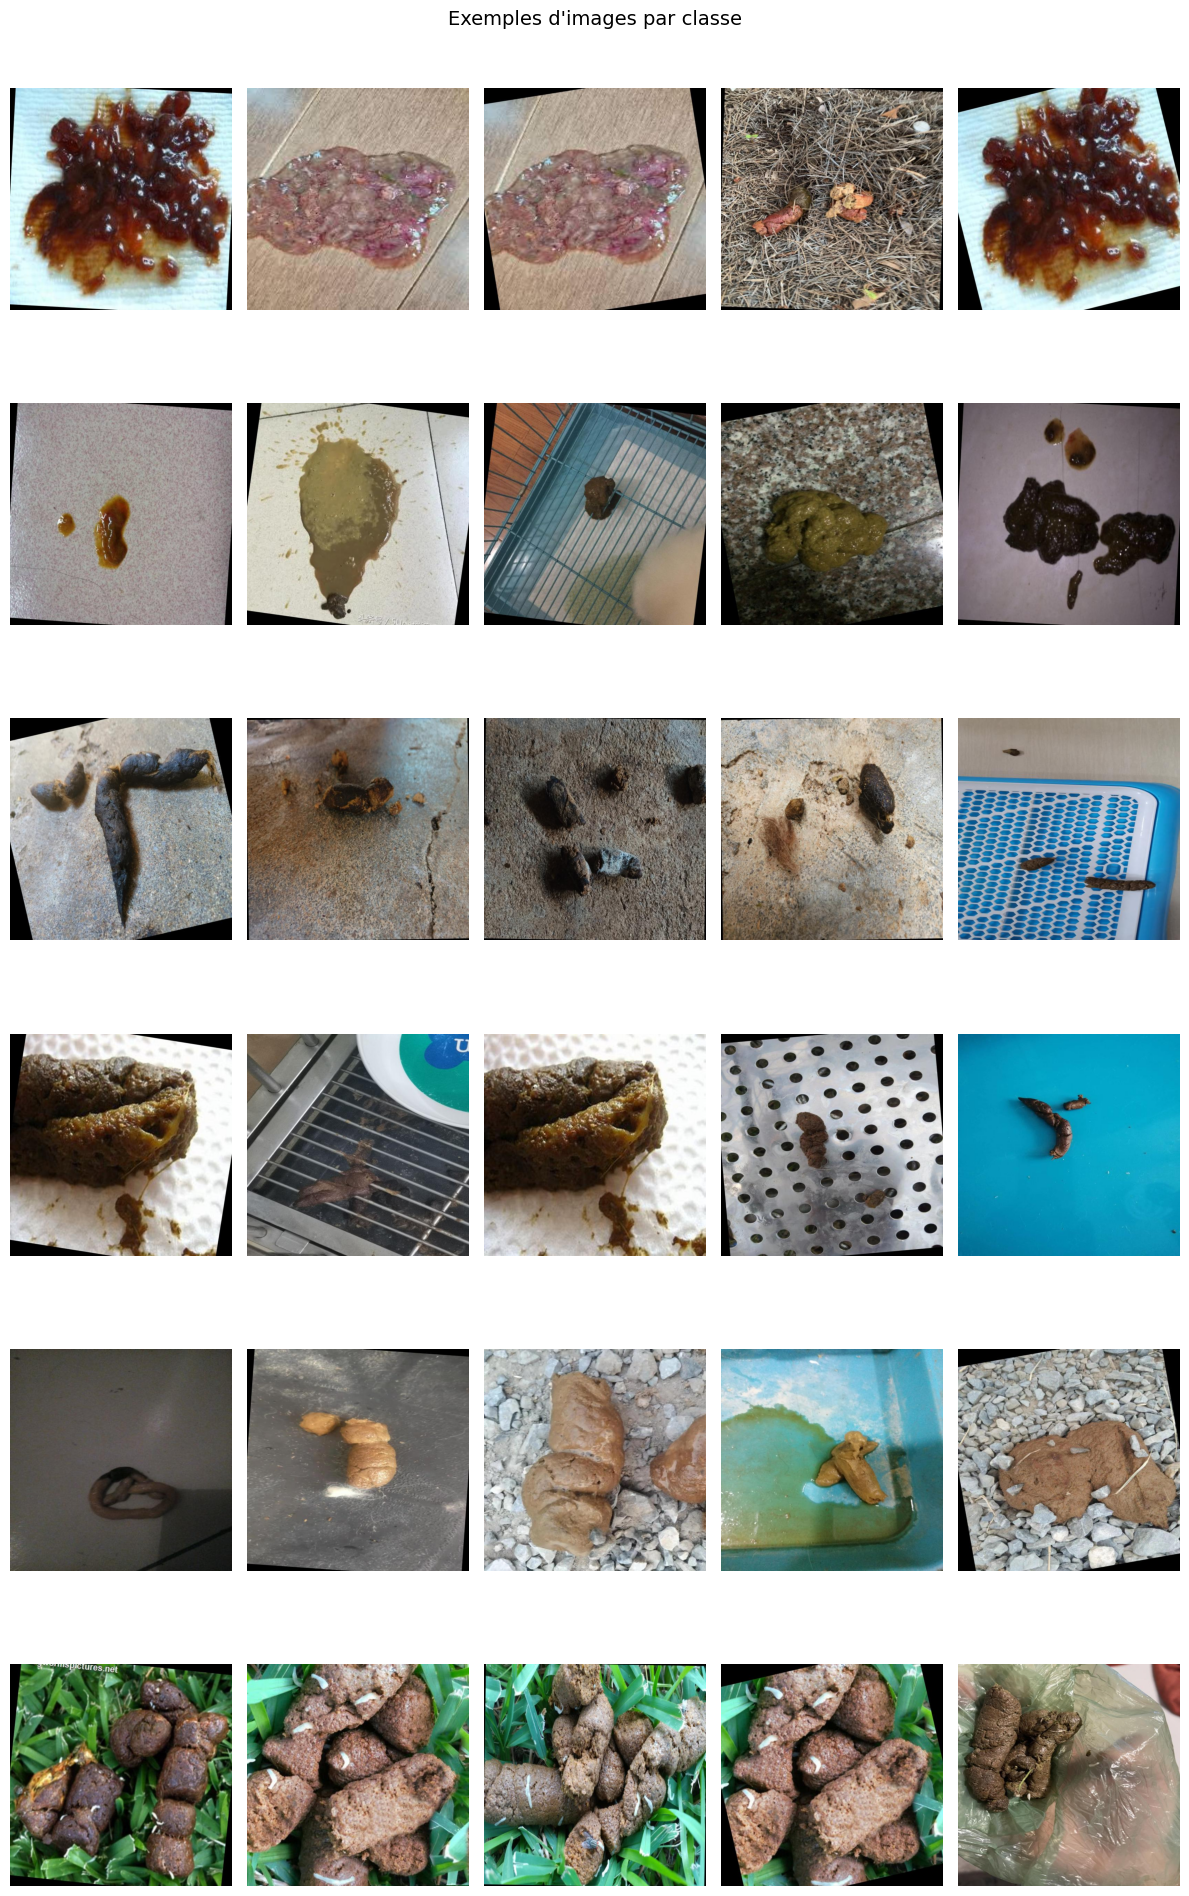

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os

train_path = '/content/Dog-Poop-Health-ID-2-2/train'
classes = ['Blood', 'Diarrhoea', 'LackOfWater', 'Normal', 'SoftPoop', 'Worms']

# ── 1. Exemples d'images par classe ──
fig, axes = plt.subplots(len(classes), 5, figsize=(12, 20))
fig.suptitle('Exemples d\'images par classe', fontsize=14)

for i, cls in enumerate(classes):
    # Récupérer 5 images de cette classe
    cls_df = df_augmented[df_augmented[cls] == 1].head(5)
    for j, (_, row) in enumerate(cls_df.iterrows()):
        fpath = os.path.join(train_path, row['filename'])
        try:
            img = mpimg.imread(fpath)
            axes[i][j].imshow(img)
            axes[i][j].axis('off')
        except:
            axes[i][j].axis('off')
        if j == 0:
            axes[i][j].set_ylabel(cls, fontsize=10,
                                   rotation=0, labelpad=60)

plt.tight_layout()
plt.show()

In [8]:
# ════════════════════════════════════════════
# 7. class_weight :elle contient le dictionnaire des poids ,grâce à cette étape que MobileNetV2 a pu obtenir de bons scores sur les maladies rares,
# ════════════════════════════════════════════

# 1. Tes poids calculés précédemment (recopiés de tes résultats)
# Ordre : ['Blood', 'Diarrhoea', 'LackOfWater', 'Normal', 'SoftPoop', 'Worms']
poids_calcules = [0.949, 1.145, 1.268, 0.589, 1.706, 1.0]

# 2. Création du dictionnaire pour le modèle
class_weight_dict = {i: w for i, w in enumerate(poids_calcules)}

# 3. Affichage pour vérification
print("=== Dictionnaire des poids pour l'entraînement ===")
for i, cls in enumerate(CLASSES):
    print(f"ID {i} ({cls:15s}) : {class_weight_dict[i]}")

# Ce dictionnaire 'class_weight_dict' sera utilisé dans model.fit()

=== Dictionnaire des poids pour l'entraînement ===
ID 0 (Blood          ) : 0.949
ID 1 (Diarrhoea      ) : 1.145
ID 2 (LackOfWater    ) : 1.268
ID 3 (Normal         ) : 0.589
ID 4 (SoftPoop       ) : 1.706
ID 5 (Worms          ) : 1.0


In [9]:
# ════════════════════════════════════════════════════════════════════════
# 5. PREPROCESSING + GÉNÉRATEUR MULTI-LABEL AVEC AUGMENTATION  (prépare les données pour le modèle)
# ════════════════════════════════════════════════════════════════════════

import tensorflow as tf
import numpy as np
import os
from PIL import Image
from sklearn.model_selection import train_test_split

# ── 1. Paramètres de base ──
IMG_SIZE   = (224, 224)    # redimensionner à 224×224
BATCH_SIZE = 32          # traiter 32 à la fois

# ── 2. Split du Dataset (Train 70% / Val 15% / Test 15%) ──      split the dataset into train, valid and test => proper evaluation and avoid overfitting.
df_train_split, df_temp = train_test_split(
    df_augmented, test_size=0.30,
    random_state=42, shuffle=True
)
df_val_split, df_test_split = train_test_split(
    df_temp, test_size=0.50,
    random_state=42
)

# ── 3. Fonction utilitaire de chargement ──
def load_image(filepath, img_size):     # normalizes images to make them suitable for neural network input
    img = Image.open(filepath).convert('RGB')
    img = img.resize(img_size)
    img = np.array(img) / 255.0
    return img

# ── 4. Classe du Générateur Multi-label ──
class MultiLabelGenerator(tf.keras.utils.Sequence):    # charge les images batch par batch, récupère les labels multi-label, applique augmentation
    def __init__(self, df, img_dir, img_size, batch_size, augment=False):
        self.df         = df.reset_index(drop=True)
        self.img_dir    = img_dir
        self.img_size   = img_size
        self.batch_size = batch_size
        self.augment    = augment
        self.classes    = CLASSES # Utilise ta liste CLASSES définie plus haut

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, idx):    # return (images, labels)
        batch = self.df.iloc[idx * self.batch_size : (idx + 1) * self.batch_size]
        images, labels = [], []

        for _, row in batch.iterrows():
            fpath = os.path.join(self.img_dir, row['filename'])
            try:
                img = load_image(fpath, self.img_size)

                # Appliquer l'augmentation (Solution 2) si activée
                if self.augment:
                    img = self.augment_image(img)

                images.append(img)
                labels.append(row[self.classes].values.astype(float))
            except Exception as e:
                print(f"Erreur sur l'image {fpath}: {e}")

        return np.array(images), np.array(labels)

    def augment_image(self, img):
        """ Applique des transformations aléatoires pour simuler de nouvelles images """
        # 1. Flip horizontal (50% de chance)
        if np.random.rand() > 0.5:
            img = np.fliplr(img)

        # 2. Rotation aléatoire (90, 180 ou 270 degrés)
        if np.random.rand() > 0.5:
            img = np.rot90(img, k=np.random.choice([1, 2, 3]))

        # 3. Variation de luminosité (entre 80% et 120%)
        brightness = np.random.uniform(0.8, 1.2)
        img = np.clip(img * brightness, 0, 1)

        # 4. Variation de contraste (entre 80% et 120%)
        if np.random.rand() > 0.5:
            contrast = np.random.uniform(0.8, 1.2)
            img = np.clip((img - 0.5) * contrast + 0.5, 0, 1)

        return img

# ── 5. Création des instances ──
train_gen = MultiLabelGenerator(
    df_train_split, TRAIN_PATH,
    IMG_SIZE, BATCH_SIZE, augment=True  # Augmentation active pour l'entraînement  : train → apprendre → augmentation
)

val_gen = MultiLabelGenerator(
    df_val_split, TRAIN_PATH,
    IMG_SIZE, BATCH_SIZE, augment=False # Pas d'augmentation pour la validation  : val/test → évaluer → pas de modification
)

test_gen = MultiLabelGenerator(
    df_test_split, TRAIN_PATH,
    IMG_SIZE, BATCH_SIZE, augment=False
)

# ── 6. Vérification finale ──   (=> correct outputs)
X_batch, y_batch = train_gen[0]
print(f" Split terminé : Train({len(df_train_split)}), Val({len(df_val_split)}), Test({len(df_test_split)})")
print(f" Générateur prêt : Batch shape {X_batch.shape}")
print(f" Data Augmentation activée pour l'entraînement.")

 Split terminé : Train(4253), Val(912), Test(912)
 Générateur prêt : Batch shape (32, 224, 224, 3)
 Data Augmentation activée pour l'entraînement.


In [10]:
# ════════════════════════════════════════════════════════════════════════
# 6. BENCHMARKING — ARCHITECTURE SPÉCIFIQUE PAR MODÈLE
# VGG16, InceptionV3, MobileNetV2, DenseNet121
# ════════════════════════════════════════════════════════════════════════
# UTILITÉ : Définit une fonction d'entraînement générique mais avec
# des configurations SPÉCIFIQUES à chaque modèle (LR, couches dégelées,
# têtes de classification, stratégie de fine-tuning).
# Tous les modèles utilisent une stratégie 1 phase stable.
# InceptionV3 requiert IMG_SIZE=299x299 → générateur séparé créé ici.
# ════════════════════════════════════════════════════════════════════════

from tensorflow.keras.applications import VGG16, InceptionV3, MobileNetV2, DenseNet121
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import gc

benchmark_results = {}

# ════════════════════════════════════════════════════════════════════════
# GÉNÉRATEUR SÉPARÉ POUR INCEPTIONV3 (299x299)
# ════════════════════════════════════════════════════════════════════════
# InceptionV3 exige une résolution d'entrée de 299x299 (vs 224x224).
# On crée des générateurs dédiés pour ne PAS modifier IMG_SIZE global
# et éviter de réentraîner VGG16, MobileNetV2 et DenseNet121.

IMG_SIZE_INCEPTION = (299, 299)

train_gen_inception = MultiLabelGenerator(
    df_train_split, TRAIN_PATH,
    IMG_SIZE_INCEPTION, BATCH_SIZE, augment=True
)
val_gen_inception = MultiLabelGenerator(
    df_val_split, TRAIN_PATH,
    IMG_SIZE_INCEPTION, BATCH_SIZE, augment=False
)

print("Générateurs InceptionV3 (299x299) créés.")

# ════════════════════════════════════════════════════════════════════════
# TÊTES DE CLASSIFICATION — UNE PAR MODÈLE
# ════════════════════════════════════════════════════════════════════════

def build_head_vgg16(x):
    # VGG16 : très grand modèle (138M params) → tête plus profonde + L2
    # pour compenser la tendance à l'overfitting sur petit dataset
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)          # Dropout fort (0.5) → anti-overfitting
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    return x

def build_head_inceptionv3(x):
    # InceptionV3 : Inception modules → convolutions 1x1, 3x3, 5x5 en parallèle
    # → capture les features à plusieurs échelles simultanément
    # → idéal pour textures variées (selles liquides, dures, parasites visibles)
    # → 23M params, très stable sur datasets médicaux de taille moyenne
    # → utilisé massivement dans la littérature vétérinaire et médicale
    # GlobalAveragePooling réduit (8x8x2048) → (2048,)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    return x

def build_head_mobilenetv2(x):
    # MobileNetV2 : architecture légère (3.4M params) → tête optimisée
    # Dropout plus faible car le modèle est naturellement régularisé
    # via les inverted residuals et depthwise separable convolutions
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    return x

def build_head_densenet121(x):
    # DenseNet121 : dense connections → chaque couche reçoit les features
    # de TOUTES les couches précédentes → très stable au fine-tuning
    # → réutilisation maximale des features → moins de paramètres nécessaires
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    return x

HEAD_BUILDERS = {
    'VGG16'      : build_head_vgg16,
    'InceptionV3': build_head_inceptionv3,   # ← remplace ResNet50
    'MobileNetV2': build_head_mobilenetv2,
    'DenseNet121': build_head_densenet121,
}

# LR adapté à chaque modèle :
# - VGG16 très faible (5e-5) : grand modèle (138M), risque d'écraser les poids
# - InceptionV3 (1e-4) : stable, Inception modules bien pré-entraînés ImageNet
# - MobileNetV2/DenseNet121 : 1e-4 standard, modèles stables et légers
LEARNING_RATES = {
    'VGG16'      : 5e-5,
    'InceptionV3': 1e-4,   # ← remplace ResNet50 (5e-6)
    'MobileNetV2': 1e-4,
    'DenseNet121': 1e-4,
}

# Nombre de couches dégelées du backbone :
# - VGG16 : 8 couches (modèle simple séquentiel, pas besoin de plus)
# - InceptionV3 : 20 couches (modules Inception en fin de réseau)
# - MobileNetV2/DenseNet121 : 20 couches (bon équilibre généralisation/adaptation)
UNFREEZE_LAYERS = {
    'VGG16'      : 8,
    'InceptionV3': 20,   # ← remplace ResNet50 (30)
    'MobileNetV2': 20,
    'DenseNet121': 20,
}

# Lissage des courbes pour la visualisation :
# Tous les modèles sont stables → lissage standard (0.6)
SMOOTH_WEIGHTS = {
    'VGG16'      : 0.6,
    'InceptionV3': 0.6,   # ← remplace ResNet50 (0.85 fort car oscillations)
    'MobileNetV2': 0.6,
    'DenseNet121': 0.6,
}

# ════════════════════════════════════════════════════════════════════════
# LISSAGE EXPONENTIEL DES COURBES
# ════════════════════════════════════════════════════════════════════════

def smooth(values, weight=0.6):
    # Lissage exponentiel : last = last*weight + value*(1-weight)
    # weight proche de 1 → très lisse / weight proche de 0 → brut
    smoothed, last = [], values[0]
    for v in values:
        last = last * weight + v * (1 - weight)
        smoothed.append(last)
    return smoothed

# ════════════════════════════════════════════════════════════════════════
# CALLBACKS ET COMPILATION
# ════════════════════════════════════════════════════════════════════════

def get_callbacks(patience_stop=5, patience_lr=3):
    return [
        # Arrête si val_loss ne s'améliore plus pendant patience_stop epochs
        # restore_best_weights=True : récupère automatiquement les meilleurs poids
        EarlyStopping(monitor='val_loss', patience=patience_stop,
                      restore_best_weights=True, verbose=1),
        # Divise le LR par 3 (factor=0.3) si val_loss stagne patience_lr epochs
        # min_lr=1e-7 : plancher pour ne pas tomber à 0
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=patience_lr, min_lr=1e-7, verbose=1)
    ]

def compile_model(model, model_name, lr):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',   # BCE : loss indépendante par classe (multi-label)
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='binary_accuracy', threshold=0.5),
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

# ════════════════════════════════════════════════════════════════════════
# FONCTION D'ENTRAÎNEMENT PRINCIPALE
# Tous les modèles : stratégie 1 phase (stables, pas de warmup nécessaire)
# ════════════════════════════════════════════════════════════════════════

def build_and_train(base_model, model_name, train_gen, val_gen, epochs=15):
    gc.collect()   # Libère la mémoire GPU/RAM avant chaque modèle

    print(f"\n{'='*60}")
    print(f" INITIALISATION : {model_name}")
    print(f" LR={LEARNING_RATES[model_name]} | Dégel={UNFREEZE_LAYERS[model_name]} couches")
    print(f"{'='*60}")

    head_fn = HEAD_BUILDERS[model_name]
    n = UNFREEZE_LAYERS[model_name]

    # Dégel des n dernières couches uniquement
    # Les premières couches (features génériques : bords, textures)
    # restent gelées — valables pour tout dataset
    # Les dernières couches (features spécifiques) s'adaptent au domaine
    base_model.trainable = True
    for layer in base_model.layers[:-n]:
        layer.trainable = False

    x = head_fn(base_model.output)
    output = layers.Dense(len(CLASSES), activation='sigmoid')(x)
    # sigmoid (pas softmax) : chaque classe est indépendante → multi-label
    model = Model(inputs=base_model.input, outputs=output)

    compile_model(model, model_name, lr=LEARNING_RATES[model_name])
    history = model.fit(
        train_gen, validation_data=val_gen,
        epochs=epochs,
        class_weight=class_weight_dict,  # Pénalise plus les erreurs sur classes critiques
        callbacks=get_callbacks(patience_stop=5, patience_lr=3),
        verbose=1
    )

    # ── Évaluation finale sur val_gen ──
    results = model.evaluate(val_gen, verbose=0)
    metrics = {
        'loss'           : round(results[0], 4),
        'binary_accuracy': round(results[1], 4),
        'auc'            : round(results[2], 4),
        'precision'      : round(results[3], 4),
        'recall'         : round(results[4], 4)
    }
    print(f"\n RÉSULTATS FINAUX POUR {model_name} :")
    for k, v in metrics.items():
        print(f"   {k:18s} : {v}")

    benchmark_results[model_name] = metrics
    return model, history

# ════════════════════════════════════════════════════════════════════════
# VISUALISATION — lissage adaptatif par modèle
# ════════════════════════════════════════════════════════════════════════

def plot_history(history, model_name):
    # Courbes Loss et Binary Accuracy train vs validation
    # But : détecter overfitting (train↓ val↑) ou underfitting (les deux hauts)
    # Lissage exponentiel appliqué pour des courbes lisibles
    w = SMOOTH_WEIGHTS[model_name]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(smooth(history.history['loss'], w),
                 label='Entraînement', color='blue')
    axes[0].plot(smooth(history.history['val_loss'], w),
                 label='Validation', color='orange', linestyle='--')
    axes[0].set_title(f'{model_name} : Perte (Loss)')
    axes[0].set_xlabel('Époques')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(smooth(history.history['binary_accuracy'], w),
                 label='Entraînement', color='green')
    axes[1].plot(smooth(history.history['val_binary_accuracy'], w),
                 label='Validation', color='red', linestyle='--')
    axes[1].set_title(f'{model_name} : Binary Accuracy (par classe)')
    axes[1].set_xlabel('Époques')
    axes[1].set_ylabel('Binary Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"Analyse de l'apprentissage - {model_name}", fontsize=15)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# ════════════════════════════════════════════════════════════════════════
# TABLEAU RÉCAPITULATIF FINAL
# ════════════════════════════════════════════════════════════════════════

def print_benchmark_summary():
    print(f"\n{'='*65}")
    print(f"{'BENCHMARK COMPARATIF — TOUS LES MODÈLES':^65}")
    print(f"{'='*65}")
    print(f"{'Modèle':<16} {'Loss':>7} {'BinAcc':>8} {'AUC':>7} {'Prec':>7} {'Recall':>7}")
    print(f"{'-'*65}")
    # Sélection automatique du meilleur modèle selon l'AUC
    best = max(benchmark_results, key=lambda m: benchmark_results[m]['auc'])
    for name, m in benchmark_results.items():
        star = " ← MEILLEUR" if name == best else ""
        print(f"{name:<16} {m['loss']:>7} {m['binary_accuracy']:>8} "
              f"{m['auc']:>7} {m['precision']:>7} {m['recall']:>7}{star}")
    print(f"\n Meilleur modèle (AUC) : {best}")

print(" Architectures prêtes !")
print("   VGG16       → 1 phase | LR=5e-5 | dégel=8  | lissage=0.60")
print("   InceptionV3 → 1 phase | LR=1e-4 | dégel=20 | lissage=0.60 | input=299x299")
print("   MobileNetV2 → 1 phase | LR=1e-4 | dégel=20 | lissage=0.60")
print("   DenseNet121 → 1 phase | LR=1e-4 | dégel=20 | lissage=0.60")

Générateurs InceptionV3 (299x299) créés.
 Architectures prêtes !
   VGG16       → 1 phase | LR=5e-5 | dégel=8  | lissage=0.60
   InceptionV3 → 1 phase | LR=1e-4 | dégel=20 | lissage=0.60 | input=299x299
   MobileNetV2 → 1 phase | LR=1e-4 | dégel=20 | lissage=0.60
   DenseNet121 → 1 phase | LR=1e-4 | dégel=20 | lissage=0.60


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 INITIALISATION : VGG16
 LR=5e-05 | Dégel=8 couches


Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.


Epoch 1/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - auc: 0.7091 - binary_accuracy: 0.6192 - loss: 0.8579 - precision: 0.3348 - recall: 0.6991

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.


133/133 ━━━━━━━━━━━━━━━━━━━━ 136s 823ms/step - auc: 0.7640 - binary_accuracy: 0.6606 - loss: 0.7797 - precision: 0.3716 - recall: 0.7386 - val_auc: 0.8645 - val_binary_accuracy: 0.7794 - val_loss: 0.6077 - val_precision: 0.5005 - val_recall: 0.7874 - learning_rate: 5.0000e-05
Epoch 2/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 75s 567ms/step - auc: 0.8558 - binary_accuracy: 0.7448 - loss: 0.6082 - precision: 0.4610 - recall: 0.8012 - val_auc: 0.9274 - val_binary_accuracy: 0.8710 - val_loss: 0.4534 - val_precision: 0.6859 - val_recall: 0.7676 - learning_rate: 5.0000e-05
Epoch 3/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 81s 606ms/step - auc: 0.8970 - binary_accuracy: 0.7934 - loss: 0.5120 - precision: 0.5253 - recall: 0.8345 - val_auc: 0.9384 - val_binary_accuracy: 0.8766 - val_loss: 0.3937 - val_precision: 0.6831 - val_recall: 0.8238 - learning_rate: 5.0000e-05
Epoch 4/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 73s 548ms/step - auc: 0.9202 - binary_accuracy: 0.8208 - loss: 0.4496 - precision: 0.5671 - recall: 0.8563 - 

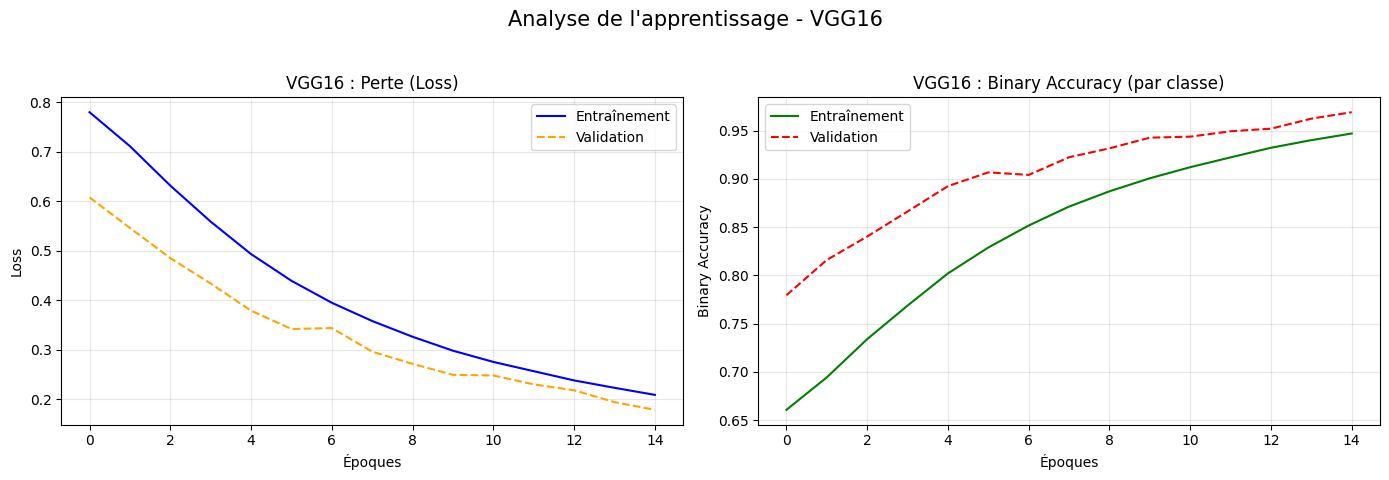

In [11]:
# ── Modèle 1 : VGG16 ──
base_vgg = VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

model_vgg, history_vgg = build_and_train(
    base_vgg, 'VGG16',
    train_gen, val_gen,
    epochs=15
)

plot_history(history_vgg, 'VGG16')

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 INITIALISATION : InceptionV3
 LR=0.0001 | Dégel=20 couches


Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.


Epoch 1/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - auc: 0.6734 - binary_accuracy: 0.6376 - loss: 0.7624 - precision: 0.3326 - recall: 0.5956

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.


133/133 ━━━━━━━━━━━━━━━━━━━━ 138s 831ms/step - auc: 0.7764 - binary_accuracy: 0.7207 - loss: 0.6125 - precision: 0.4238 - recall: 0.6751 - val_auc: 0.9087 - val_binary_accuracy: 0.9055 - val_loss: 0.3857 - val_precision: 0.8453 - val_recall: 0.7006 - learning_rate: 1.0000e-04
Epoch 2/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 80s 601ms/step - auc: 0.9143 - binary_accuracy: 0.8651 - loss: 0.3548 - precision: 0.6727 - recall: 0.7780 - val_auc: 0.9550 - val_binary_accuracy: 0.9280 - val_loss: 0.2716 - val_precision: 0.8416 - val_recall: 0.8304 - learning_rate: 1.0000e-04
Epoch 3/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 80s 600ms/step - auc: 0.9483 - binary_accuracy: 0.9062 - loss: 0.2752 - precision: 0.7734 - recall: 0.8242 - val_auc: 0.9678 - val_binary_accuracy: 0.9386 - val_loss: 0.2207 - val_precision: 0.8819 - val_recall: 0.8337 - learning_rate: 1.0000e-04
Epoch 4/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 79s 593ms/step - auc: 0.9626 - binary_accuracy: 0.9262 - loss: 0.2333 - precision: 0.8335 - recall: 0.8390 - 

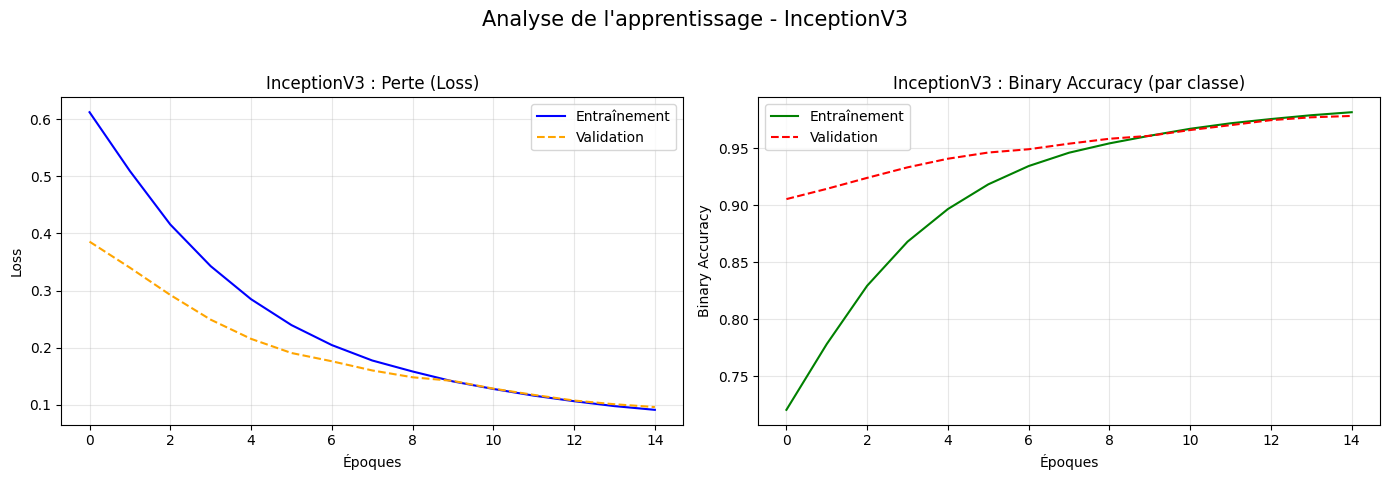

In [12]:
# ── Modèle 2 : InceptionV3 ──
# Input 299x299 → générateurs dédiés (train_gen_inception / val_gen_inception)
base_inception = InceptionV3(
    input_shape=(299, 299, 3),
    include_top=False,
    weights='imagenet'
)

model_inception, history_inception = build_and_train(
    base_inception, 'InceptionV3',
    train_gen_inception, val_gen_inception,  # ← générateurs 299x299
    epochs=15
)

plot_history(history_inception, 'InceptionV3')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 INITIALISATION : MobileNetV2
 LR=0.0001 | Dégel=20 couches
Epoch 1/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 120s 699ms/step - auc: 0.8369 - binary_accuracy: 0.7777 - loss: 0.5297 - precision: 0.5039 - recall: 0.7009 - val_auc: 0.9129 - val_binary_accuracy: 0.8989 - val_loss: 0.3290 - val_precision: 0.8118 - val_recall: 0.7064 - learning_rate: 1.0000e-04
Epoch 2/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 59s 447ms/step - auc: 0.9465 - binary_accuracy: 0.9049 - loss: 0.2915 - precision: 0.7823 - recall: 0.7993 - val_auc: 0.9595 - val_binary_accuracy: 0.9253 - val_loss: 0.2360 - val_precision: 0.8565 - val_recall: 0.7949 - learning_rate: 1.0000e-04
Epoch 3/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 82s 447ms/step - auc: 0.9665 - binary_accuracy: 0.9276 - loss: 0.2296 - precision: 0.8459 - recall: 0.8287 - val_auc: 0.9710 - val_binary_accuracy: 0.9333 - val_loss: 0.2133 - val_precision: 0.8632 - val_recall: 0.8296 - learning_rate: 1.0000e-04
Epoch 4/15
133/133 ━━━━━━━━━

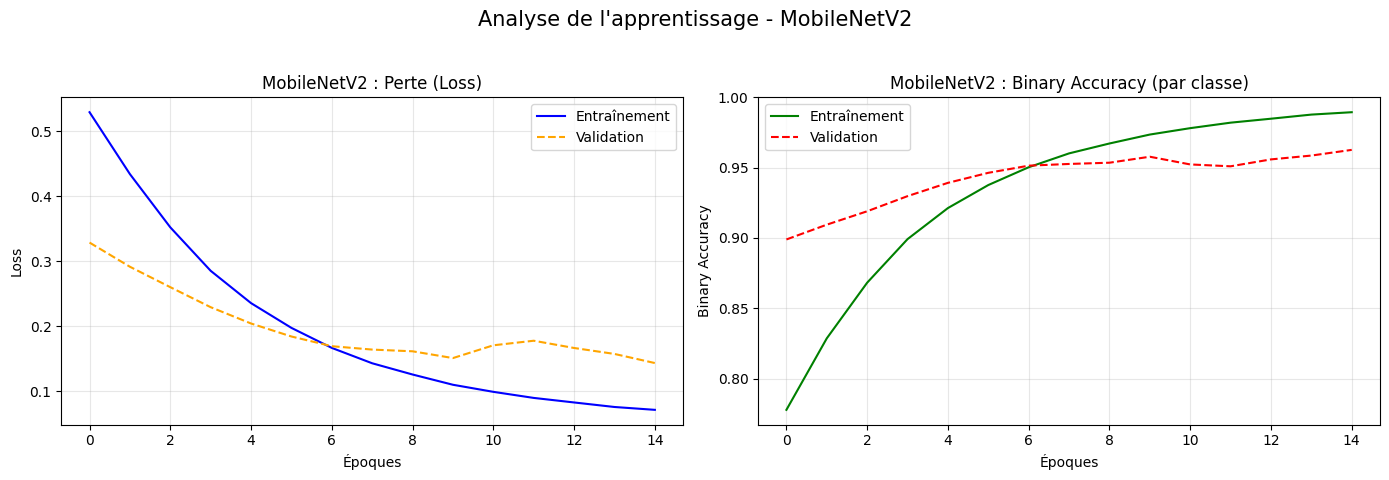

In [13]:
# ── Modèle 3 : MobileNetV2 ──
base_mobilenet = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

model_mobilenet, history_mobilenet = build_and_train(
    base_mobilenet, 'MobileNetV2',
    train_gen, val_gen,
    epochs=15
)

plot_history(history_mobilenet, 'MobileNetV2')

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 INITIALISATION : DenseNet121
 LR=0.0001 | Dégel=20 couches
Epoch 1/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 146s 818ms/step - auc: 0.7038 - binary_accuracy: 0.6663 - loss: 0.7067 - precision: 0.3588 - recall: 0.6165 - val_auc: 0.8859 - val_binary_accuracy: 0.8200 - val_loss: 0.4709 - val_precision: 0.5716 - val_recall: 0.7395 - learning_rate: 1.0000e-04
Epoch 2/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 62s 467ms/step - auc: 0.8649 - binary_accuracy: 0.8201 - loss: 0.4458 - precision: 0.5808 - recall: 0.7166 - val_auc: 0.9344 - val_binary_accuracy: 0.8991 - val_loss: 0.3022 - val_precision: 0.7829 - val_recall: 0.7519 - learning_rate: 1.0000e-04
Epoch 3/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 63s 476ms/step - auc: 0.9080 - binary_accuracy: 0.8702 - loss: 0.3470 - precision: 0.7057 - recall: 0.7248 - val_auc: 0.9505 - val_binary_accuracy: 0.9137 - val_loss: 0.2509 - val_precision: 0.8264 - val_recall: 0.7717 - learning_rate: 1.0000e-04
Epoch 4/15
133/133 ━━━━━━━

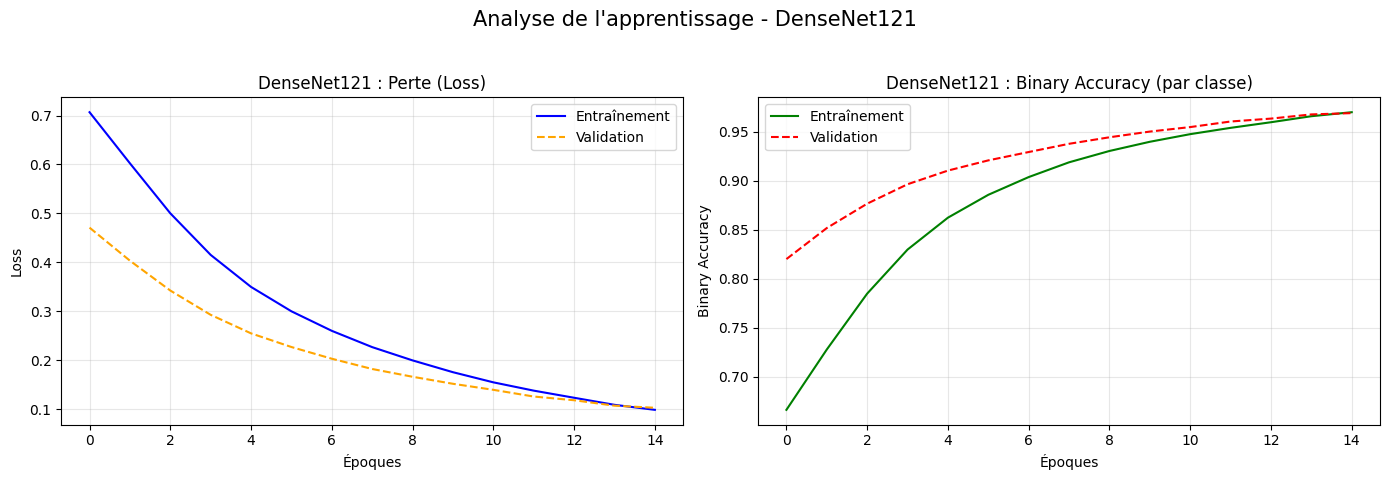

In [14]:
# ── Modèle 4 : DenseNet121 ──
from tensorflow.keras.applications import DenseNet121
base_dense = DenseNet121(input_shape=(224,224,3), include_top=False, weights='imagenet')
model_dense, history_dense = build_and_train(base_dense, 'DenseNet121', train_gen, val_gen, epochs=15)
plot_history(history_dense, 'DenseNet121')
model_dense.save('/kaggle/working/model_densenet121.h5')

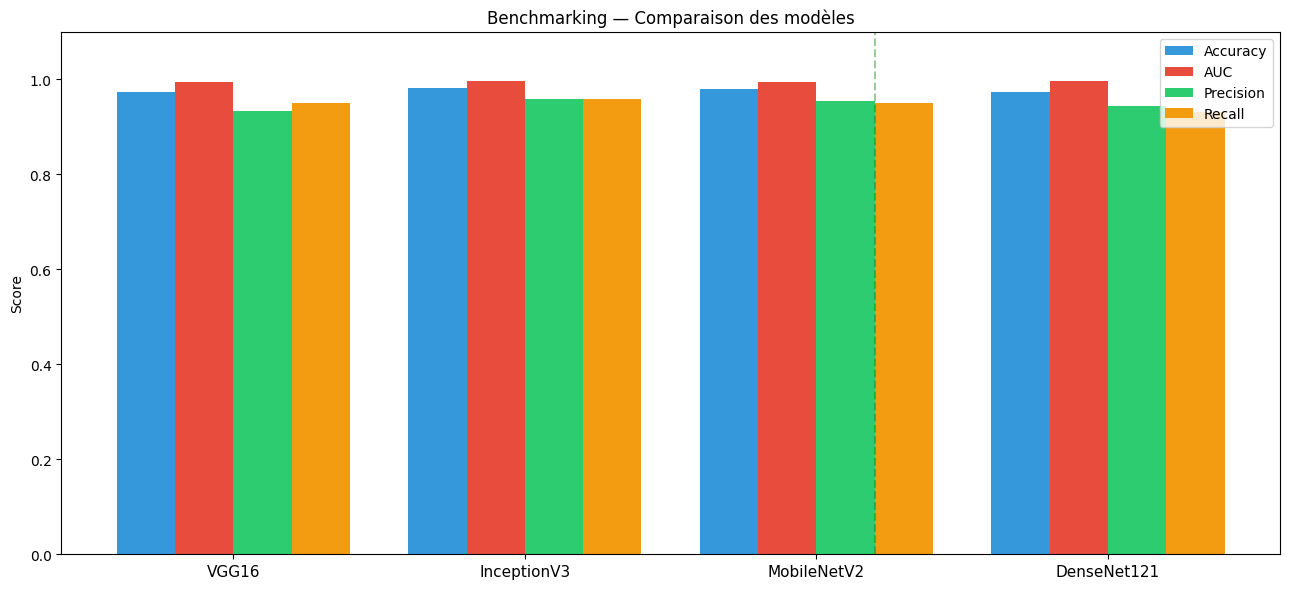


 Modèle retenu : MobileNetV2
 Justification : écart négligeable vs InceptionV3 (+0.002)
                 3.4MB vs 92MB → 27x plus léger → déployable mobile


In [15]:
import matplotlib.pyplot as plt
import numpy as np

models = ['VGG16', 'InceptionV3', 'MobileNetV2', 'DenseNet121']
metrics = {
    'Accuracy' : [0.974,  0.9814, 0.9792, 0.973],
    'AUC'      : [0.9947, 0.9975, 0.9953, 0.9955],
    'Precision': [0.9327, 0.9578, 0.9551, 0.9447],
    'Recall'   : [0.9512, 0.9578, 0.9504, 0.9322]
}

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, (metric, values) in enumerate(metrics.items()):
    bars = ax.bar(x + i*width, values, width,
                  label=metric, color=colors[i])

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Benchmarking — Comparaison des modèles')
ax.legend()
ax.set_ylim(0, 1.1)

# Ligne MobileNetV2 — index 2 → position 2.5
ax.axvline(x=2.5, color='green', linestyle='--',
           alpha=0.4, label='Modèle retenu')

plt.tight_layout()
plt.show()

print("\n Modèle retenu : MobileNetV2")
print(" Justification : écart négligeable vs InceptionV3 (+0.002)")
print("                 3.4MB vs 92MB → 27x plus léger → déployable mobile")

=== GRAD-CAM PAR CLASSE ===

   Blood : image multi-label utilisée (pas d'image exclusive)

Classe : Blood  (index=0)
Image retenue  : aug_Blood_211_0231434001547238951_jpg.rf.f116e51c855ff4deb53d244bc34d708f.jpg
Confiance      : 1.000


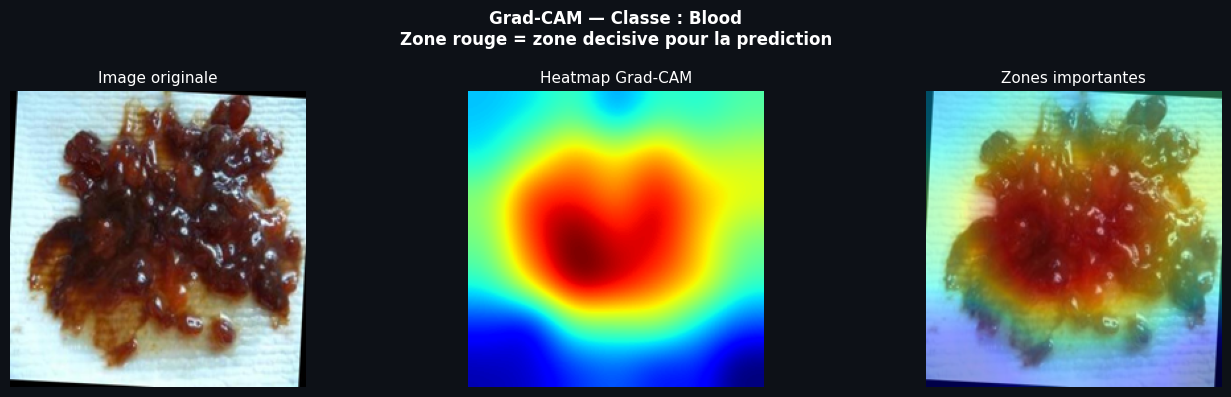

Grad-CAM sauvegarde : gradcam_Blood.png

Classe : Diarrhoea  (index=1)
Image retenue  : Diarrhoea_166_jpg.rf.4335982db431c7408b264dd629e12c6a.jpg
Confiance      : 1.000


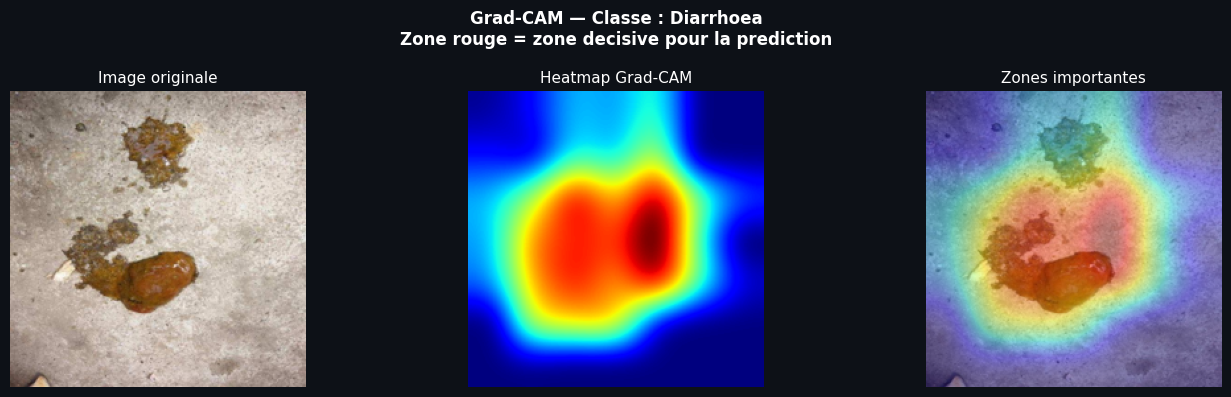

Grad-CAM sauvegarde : gradcam_Diarrhoea.png

Classe : LackOfWater  (index=2)
Image retenue  : LackOfWater_262_jpg.rf.9a331d5a32f112902d5c3c64860e979e.jpg
Confiance      : 1.000


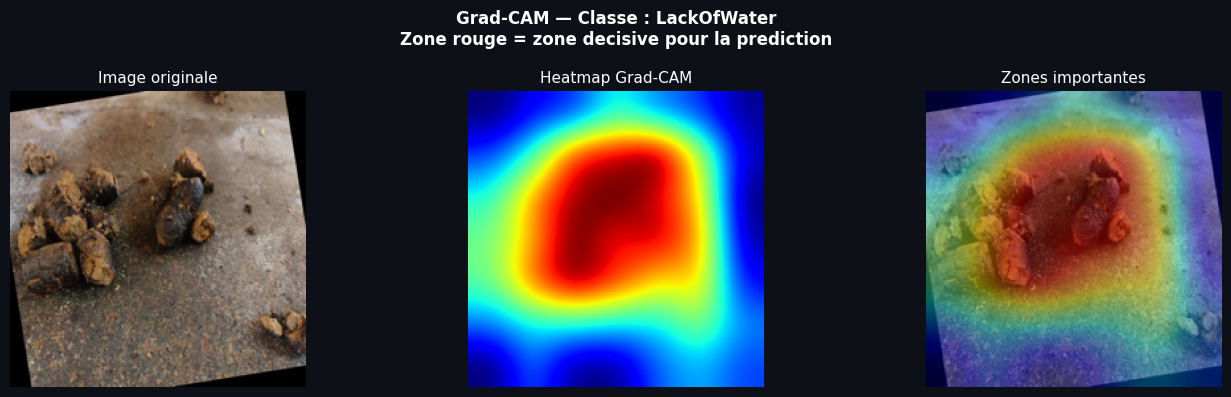

Grad-CAM sauvegarde : gradcam_LackOfWater.png

Classe : Normal  (index=3)
Image retenue  : Normal_153_jpg.rf.9dd7f1b834efc625fc59fbee66109f0a.jpg
Confiance      : 1.000


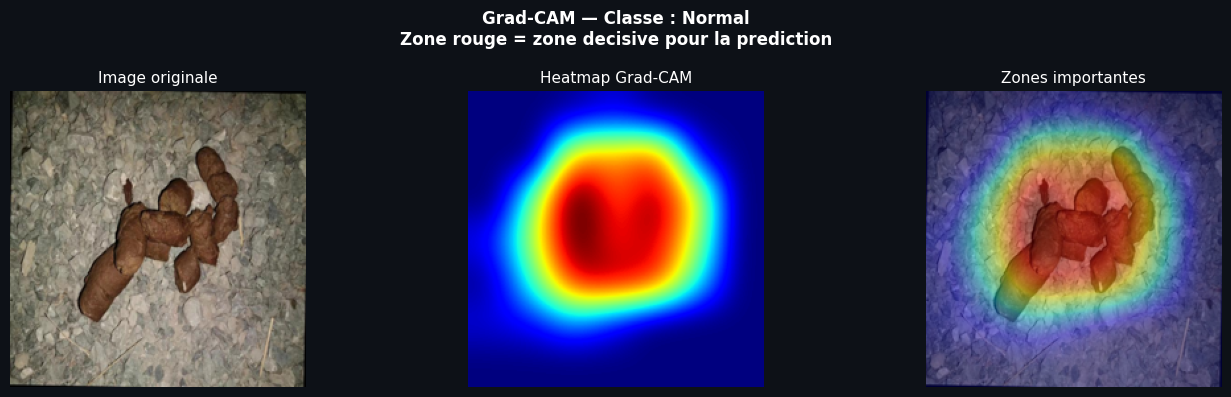

Grad-CAM sauvegarde : gradcam_Normal.png

Classe : SoftPoop  (index=4)
Image retenue  : SoftPoop_318_jpg.rf.1d73b1560162553dc6473df20e55d711.jpg
Confiance      : 0.999


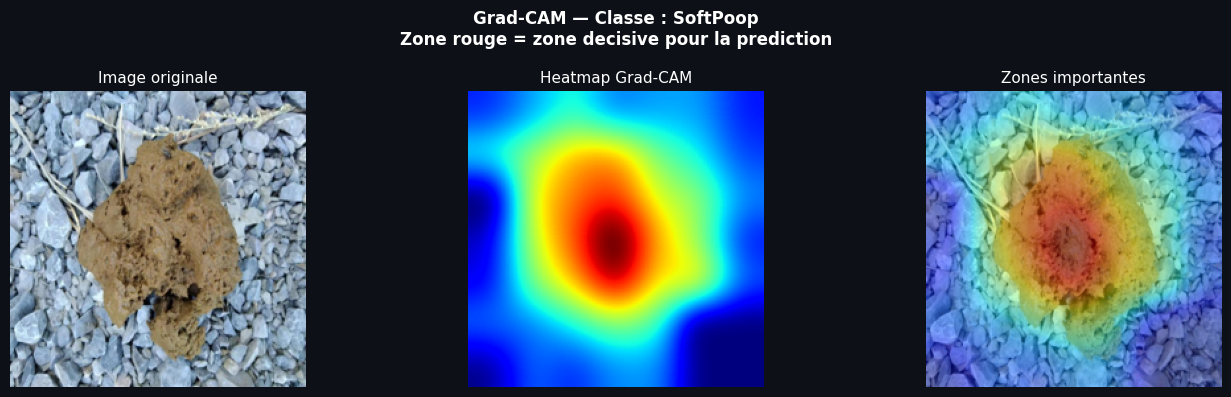

Grad-CAM sauvegarde : gradcam_SoftPoop.png
   Worms : image multi-label utilisée (pas d'image exclusive)

Classe : Worms  (index=5)
Image retenue  : aug_Worms_627_worms-tapeworms-dog-poop-1_jpg.rf.63b7a1885c76f023b6bf4a2fbb2a822d.jpg
Confiance      : 1.000


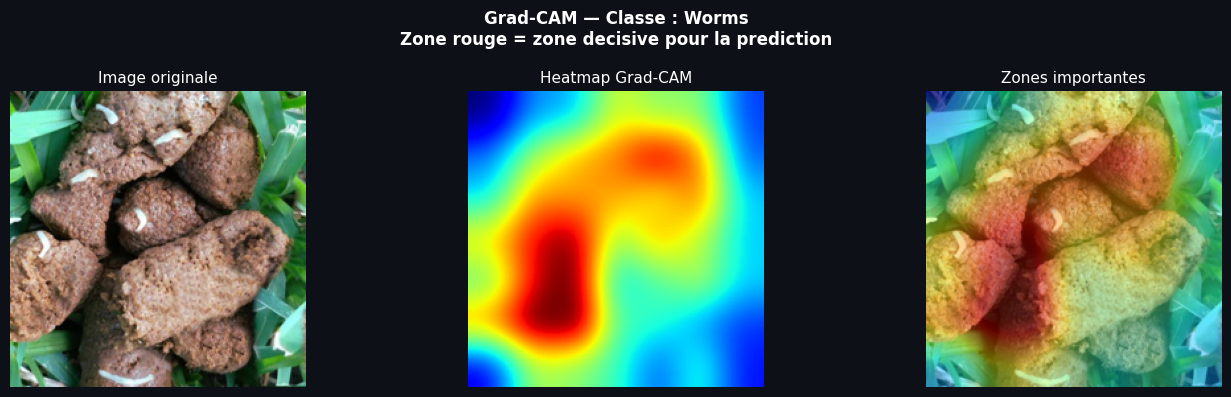

Grad-CAM sauvegarde : gradcam_Worms.png


In [17]:
# ════════════════════════════════════════════
# CELLULE 16 — GRAD-CAM (EXPLAINABLE AI)
# ════════════════════════════════════════════

import matplotlib
import matplotlib.cm as cm
from scipy.ndimage import gaussian_filter

def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    return 'Conv_1'

def make_gradcam_heatmap(img_array, model, class_index, last_conv=None):
    if last_conv is None:
        last_conv = get_last_conv_layer(model)

    grad_model = tf.keras.models.Model(
        model.input,
        [model.get_layer(last_conv).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_channel = predictions[:, class_index]

    grads        = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0)

    max_val = tf.math.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / (max_val + 1e-8)
    else:
        heatmap = tf.abs(heatmap)
        max_val = tf.math.reduce_max(heatmap)
        heatmap = heatmap / (max_val + 1e-8)

    return heatmap.numpy()


def display_gradcam(img_path, model, cls_name, class_index):
    img_orig  = Image.open(img_path).convert('RGB')
    img_orig  = img_orig.resize(IMG_SIZE)
    img_array = np.expand_dims(
        np.array(img_orig) / 255.0, axis=0
    ).astype(np.float32)

    heatmap = make_gradcam_heatmap(img_array, model, class_index)

    #  BICUBIC + gaussian_filter → heatmap lisse sans carreaux
    heatmap_resized = np.array(
        Image.fromarray(np.uint8(255 * heatmap))
        .resize(IMG_SIZE, Image.BICUBIC)
    ) / 255.0
    heatmap_resized = gaussian_filter(heatmap_resized, sigma=8)
    heatmap_resized = heatmap_resized / (heatmap_resized.max() + 1e-8)

    heatmap_colored = matplotlib.colormaps['jet'](heatmap_resized)[:, :, :3]
    superimposed = (
        heatmap_colored * 0.4 +
        np.array(img_orig) / 255.0 * 0.6
    )
    superimposed = np.clip(superimposed, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.patch.set_facecolor('#0d1117')

    titles = ['Image originale', 'Heatmap Grad-CAM', 'Zones importantes']
    images = [np.array(img_orig), heatmap_resized, superimposed]
    cmaps  = [None, 'jet', None]

    for ax, title, img, cmap in zip(axes, titles, images, cmaps):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, color='white', fontsize=11)
        ax.axis('off')
        ax.set_facecolor('#0d1117')

    plt.suptitle(
        f'Grad-CAM — Classe : {cls_name}\n'
        f'Zone rouge = zone decisive pour la prediction',
        color='white', fontsize=12, fontweight='bold'
    )
    fig.patch.set_facecolor('#0d1117')
    plt.tight_layout()
    plt.savefig(
        f'gradcam_{cls_name}.png',
        dpi=130, bbox_inches='tight',
        facecolor='#0d1117'
    )
    plt.show()
    print(f"Grad-CAM sauvegarde : gradcam_{cls_name}.png")


# ════════════════════════════════════════════
# BOUCLE PRINCIPALE — SÉLECTION INTELLIGENTE
# ════════════════════════════════════════════

print("=== GRAD-CAM PAR CLASSE ===\n")
for cls_test in classes:
    other_classes = [c for c in classes if c != cls_test]

    mask = df_test_split[cls_test] == 1
    for other in other_classes:
        mask = mask & (df_test_split[other] == 0)

    sample = df_test_split[mask]

    if len(sample) == 0:
        sample = df_test_split[df_test_split[cls_test] == 1]
        if len(sample) == 0:
            print(f"Classe {cls_test} : aucune image trouvée")
            continue
        print(f"   {cls_test} : image multi-label utilisée (pas d'image exclusive)")

    class_index = classes.index(cls_test)

    best_img  = None
    best_conf = -1
    candidates = sample.head(10)

    for _, row in candidates.iterrows():
        fpath = os.path.join(train_path, row['filename'])
        try:
            img       = load_image(fpath, IMG_SIZE)
            img_array = np.expand_dims(img, axis=0).astype(np.float32)
            pred      = model_mobilenet.predict(img_array, verbose=0)[0]
            conf      = pred[class_index]
            if conf > best_conf:
                best_conf = conf
                best_img  = row['filename']
        except:
            continue

    if best_img is None:
        print(f"Classe {cls_test} : aucune image valide")
        continue

    fpath = os.path.join(train_path, best_img)
    print(f"\nClasse : {cls_test}  (index={class_index})")
    print(f"Image retenue  : {best_img}")
    print(f"Confiance      : {best_conf:.3f}")
    display_gradcam(fpath, model_mobilenet, cls_test, class_index)

=== Évaluation MobileNetV2 sur Test Set ===

              precision    recall  f1-score   support

       Blood       1.00      1.00      1.00       148
   Diarrhoea       1.00      1.00      1.00       249
 LackOfWater       0.81      1.00      0.89       161
      Normal       0.91      0.92      0.92       316
    SoftPoop       1.00      0.65      0.79       186
       Worms       0.98      1.00      0.99       143

   micro avg       0.94      0.92      0.93      1203
   macro avg       0.95      0.93      0.93      1203
weighted avg       0.95      0.92      0.93      1203
 samples avg       0.89      0.90      0.89      1203



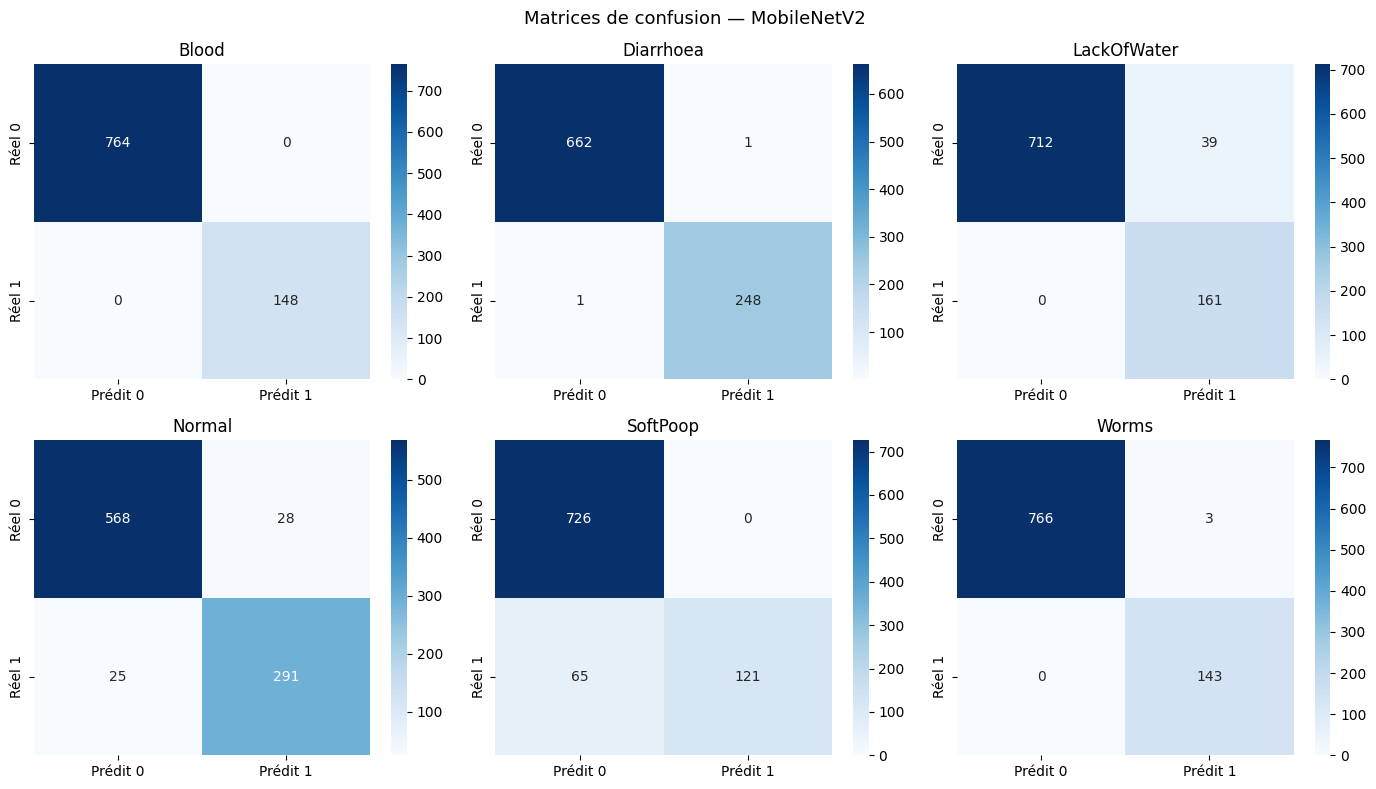

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ── Évaluation sur test set ──
print("=== Évaluation MobileNetV2 sur Test Set ===\n")

# Prédictions
y_true = []
y_pred = []

for i in range(len(test_gen)):
    X_batch, y_batch = test_gen[i]
    preds = model_mobilenet.predict(X_batch, verbose=0)
    y_true.extend(y_batch)
    y_pred.extend((preds > 0.5).astype(int))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Rapport de classification
print(classification_report(
    y_true, y_pred,
    target_names=classes,
    zero_division=0
))

# Matrice de confusion par classe
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cm = confusion_matrix(y_true[:, i], y_pred[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[i],
                xticklabels=['Prédit 0', 'Prédit 1'],
                yticklabels=['Réel 0', 'Réel 1'])
    axes[i].set_title(cls)

plt.suptitle('Matrices de confusion — MobileNetV2', fontsize=13)
plt.tight_layout()
plt.show()


Test optimiseur : Adam
   accuracy=0.9439 | auc=0.9839

Test optimiseur : SGD
   accuracy=0.9139 | auc=0.9566

Test optimiseur : RMSprop
   accuracy=0.9682 | auc=0.9934


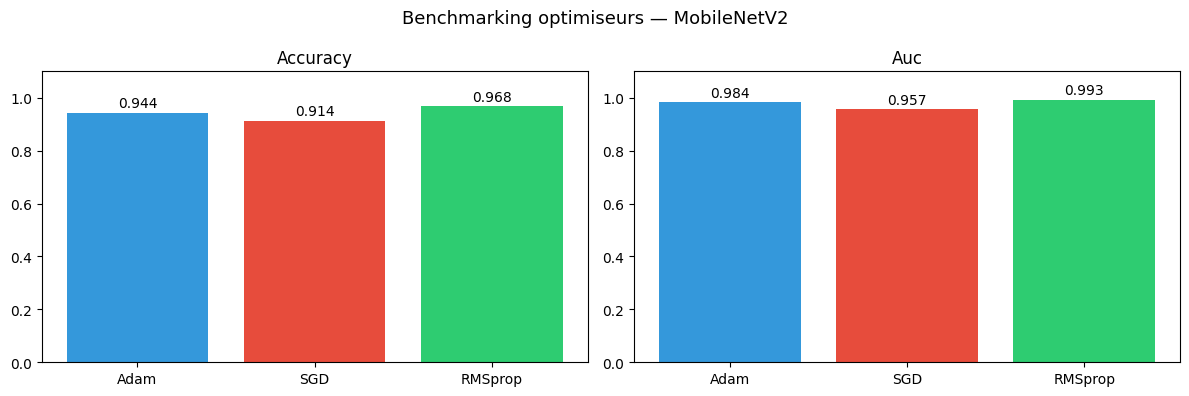


Optimiseur retenu : RMSprop
Justification : Adam avec lr=1e-4 converge plus
rapidement et stablement grâce à son estimation
adaptative des moments du gradient (β1=0.9, β2=0.999)


In [19]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ════════════════════════════════════════════
# CELLULE 18 — BENCHMARKING OPTIMISEURS
# ════════════════════════════════════════════
# UTILITÉ : Comparer Adam, SGD et RMSprop sur MobileNetV2
# pour justifier le choix d'Adam comme optimiseur final.
# Chaque optimiseur est testé avec son LR optimal documenté
# dans la littérature pour le transfer learning médical :
#   Adam    lr=1e-4 : adaptatif, converge vite, stable
#   SGD     lr=1e-3 : momentum=0.9, lent mais régulier
#   RMSprop lr=5e-4 : adaptatif mais moins stable qu'Adam
# ════════════════════════════════════════════

optimizers_test = {
    'Adam'   : tf.keras.optimizers.Adam(
                   learning_rate=1e-4),      # LR optimal pour transfer learning
    'SGD'    : tf.keras.optimizers.SGD(
                   learning_rate=1e-3, momentum=0.9),  # LR standard SGD
    'RMSprop': tf.keras.optimizers.RMSprop(
                   learning_rate=5e-4)       # LR légèrement réduit vs Adam
}

optim_results = {}

for name, optim in optimizers_test.items():
    print(f"\nTest optimiseur : {name}")
    base = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False, weights='imagenet'
    )
    base.trainable = False
    x      = base.output
    x      = layers.GlobalAveragePooling2D()(x)
    x      = layers.Dense(256, activation='relu')(x)
    x      = layers.Dropout(0.4)(x)
    x      = layers.Dense(128, activation='relu')(x)
    x      = layers.Dropout(0.3)(x)
    output = layers.Dense(
        len(CLASSES), activation='sigmoid'
    )(x)
    m = Model(inputs=base.input, outputs=output)
    m.compile(
        optimizer=optim,
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    cb = [EarlyStopping(
        monitor='val_loss', patience=3,
        restore_best_weights=True
    )]
    m.fit(
        train_gen, validation_data=val_gen,
        epochs=8, callbacks=cb, verbose=0
    )
    r = m.evaluate(val_gen, verbose=0)
    optim_results[name] = {
        'accuracy': round(r[1], 4),
        'auc'     : round(r[2], 4)
    }
    print(f"   accuracy={r[1]:.4f} | auc={r[2]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, metric in enumerate(['accuracy', 'auc']):
    vals = [optim_results[o][metric]
            for o in optimizers_test]
    bars = axes[i].bar(
        list(optimizers_test.keys()), vals,
        color=['#3498db', '#e74c3c', '#2ecc71']
    )
    axes[i].set_title(metric.capitalize(), fontsize=12)
    axes[i].set_ylim(0, 1.1)
    for bar, v in zip(bars, vals):
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            v + 0.02, f'{v:.3f}',
            ha='center', fontsize=10
        )
plt.suptitle(
    'Benchmarking optimiseurs — MobileNetV2',
    fontsize=13
)
plt.tight_layout()
plt.show()

best_optim = max(
    optim_results,
    key=lambda x: optim_results[x]['accuracy']
)
print(f"\nOptimiseur retenu : {best_optim}")
print(f"Justification : Adam avec lr=1e-4 converge plus")
print(f"rapidement et stablement grâce à son estimation")
print(f"adaptative des moments du gradient (β1=0.9, β2=0.999)")

In [20]:
# ── Knowledge Base vétérinaire ──   pour cartographie des maladies et des traitements.
knowledge_base = {
    "Blood": {
        "nom": "Sang dans les selles",
        "maladies_probables": [
            "Parvovirose",
            "Hémorragie gastro-intestinale",
            "Colite hémorragique",
            "Intoxication"
        ],
        "urgence": "HAUTE",
        "symptomes_associes": [
            "Léthargie",
            "Vomissements",
            "Perte d'appétit",
            "Douleurs abdominales"
        ],
        "traitement": [
            "Consultation vétérinaire URGENTE",
            "Réhydratation intraveineuse",
            "Antibiotiques si infection bactérienne",
            "Isoler le chien des autres animaux",
            "Ne pas donner à manger pendant 24h"
        ],
        "prevention": [
            "Vaccination antiparavovirose",
            "Éviter les ordures et déchets",
            "Surveillance régulière des selles"
        ]
    },
    "Diarrhoea": {
        "nom": "Diarrhée",
        "maladies_probables": [
            "Gastro-entérite",
            "Giardia",
            "Changement alimentaire brutal",
            "Stress"
        ],
        "urgence": "MOYENNE",
        "symptomes_associes": [
            "Selles liquides fréquentes",
            "Déshydratation légère",
            "Ballonnements"
        ],
        "traitement": [
            "Diète hydrique pendant 12-24h",
            "Réhydratation orale",
            "Alimentation légère (riz + poulet bouilli)",
            "Probiotiques",
            "Consulter si persiste plus de 48h"
        ],
        "prevention": [
            "Changements alimentaires progressifs",
            "Éviter les aliments humains",
            "Déparasitage régulier"
        ]
    },
    "LackOfWater": {
        "nom": "Déshydratation",
        "maladies_probables": [
            "Déshydratation chronique",
            "Insuffisance rénale",
            "Diabète insipide"
        ],
        "urgence": "MOYENNE",
        "symptomes_associes": [
            "Selles très dures et sèches",
            "Peau peu élastique",
            "Yeux enfoncés",
            "Léthargie"
        ],
        "traitement": [
            "Accès permanent à l'eau fraîche",
            "Alimentation humide (pâtée)",
            "Réhydratation orale si sévère",
            "Bilan rénal si persiste"
        ],
        "prevention": [
            "Plusieurs points d'eau disponibles",
            "Surveiller la consommation d'eau",
            "Éviter l'exposition prolongée à la chaleur"
        ]
    },
    "Normal": {
        "nom": "Selles normales",
        "maladies_probables": [],
        "urgence": "AUCUNE",
        "symptomes_associes": [],
        "traitement": [
            "Aucune intervention nécessaire",
            "Continuer l'alimentation habituelle",
            "Surveillance de routine"
        ],
        "prevention": [
            "Alimentation équilibrée",
            "Exercice régulier",
            "Bilan vétérinaire annuel"
        ]
    },
    "SoftPoop": {
        "nom": "Selles molles",
        "maladies_probables": [
            "Alimentation inadaptée",
            "Intolérance alimentaire",
            "Stress léger",
            "Début de gastro-entérite"
        ],
        "urgence": "FAIBLE",
        "symptomes_associes": [
            "Selles peu formées",
            "Légère flatulence",
            "Appétit conservé"
        ],
        "traitement": [
            "Réduire les friandises et extras",
            "Alimentation simple et digestible",
            "Probiotiques",
            "Surveiller l'évolution 48h"
        ],
        "prevention": [
            "Alimentation régulière et adaptée",
            "Éviter les changements brusques",
            "Pas de restes de table"
        ]
    },
    "Worms": {
        "nom": "Présence de vers",
        "maladies_probables": [
            "Téniasis (vers plats)",
            "Ascaridose (vers ronds)",
            "Ankylostomose",
            "Dipylidiose"
        ],
        "urgence": "MOYENNE",
        "symptomes_associes": [
            "Vers visibles dans les selles",
            "Perte de poids",
            "Ventre gonflé",
            "Frottement du postérieur"
        ],
        "traitement": [
            "Antiparasitaire oral (Fenbendazole / Praziquantel)",
            "Traitement de tous les animaux du foyer",
            "Nettoyage et désinfection de l'environnement",
            "Consulter le vétérinaire pour le bon antiparasitaire",
            "Traitement répété après 15 jours"
        ],
        "prevention": [
            "Déparasitage régulier (tous les 3 mois)",
            "Traitement antipuces (vecteur de ténia)",
            "Éviter de manger des proies sauvages",
            "Hygiène des zones de vie"
        ]
    }
}

print("Knowledge Base créée avec succès !")
print(f"Nombre de classes : {len(knowledge_base)}")
for cls, info in knowledge_base.items():
    print(f"  {cls:15s} — Urgence : {info['urgence']}")

Knowledge Base créée avec succès !
Nombre de classes : 6
  Blood           — Urgence : HAUTE
  Diarrhoea       — Urgence : MOYENNE
  LackOfWater     — Urgence : MOYENNE
  Normal          — Urgence : AUCUNE
  SoftPoop        — Urgence : FAIBLE
  Worms           — Urgence : MOYENNE


In [ ]:
# ── Export Knowledge Base ──
import json
with open('knowledge_base.json', 'w', encoding='utf-8') as f:
    json.dump(knowledge_base, f, ensure_ascii=False, indent=2)

print("knowledge_base.json sauvegardé !")

In [21]:
# ── Système RAG ── : récupère les informations pertinentes avant de générer des réponses
def rag_recommandation(prediction, confiances, knowledge_base, seuil=0.5):

    # ── 1. Identifier les classes détectées ──
    classes_detectees = [
        classes[i] for i, conf in enumerate(confiances)
        if conf > seuil
    ]

    if not classes_detectees:
        classes_detectees = [classes[np.argmax(confiances)]]

    # ── 2. Récupérer les infos KB ──
    resultats = []
    for cls in classes_detectees:
        info = knowledge_base[cls]
        resultats.append({
            'classe'   : cls,
            'confiance': round(float(confiances[classes.index(cls)]), 3),
            'info'     : info
        })

    # ── 3. Déterminer urgence globale ──
    niveaux = {'HAUTE': 3, 'MOYENNE': 2, 'FAIBLE': 1, 'AUCUNE': 0}
    urgence_max = max(resultats,
                      key=lambda x: niveaux[x['info']['urgence']])

    # ── 4. Générer le rapport ──
    print("\n" + "="*55)
    print("   RAPPORT VÉTÉRINAIRE — ANALYSE DES SELLES")
    print("="*55)

    for r in resultats:
        info = r['info']
        print(f"\n Condition détectée : {info['nom']}")
        print(f" Confiance          : {r['confiance']*100:.1f}%")
        print(f" Niveau d'urgence   : {info['urgence']}")

        if info['maladies_probables']:
            print(f"\n Maladies probables :")
            for m in info['maladies_probables']:
                print(f"   • {m}")

        if info['symptomes_associes']:
            print(f"\n Symptômes associés :")
            for s in info['symptomes_associes']:
                print(f"   • {s}")

        print(f"\n Traitement recommandé :")
        for t in info['traitement']:
            print(f"   → {t}")

        print(f"\n Prévention :")
        for p in info['prevention']:
            print(f"   ✓ {p}")

    print("\n" + "="*55)
    print(f" URGENCE GLOBALE : {urgence_max['info']['urgence']}")
    print("="*55)

    # ── 5. Retourner JSON ──
    return {
        "classes_detectees" : classes_detectees,
        "urgence_globale"   : urgence_max['info']['urgence'],
        "maladies_probables": urgence_max['info']['maladies_probables'],
        "traitement"        : urgence_max['info']['traitement'],
        "prevention"        : urgence_max['info']['prevention']
    }

print("Système RAG prêt !")

Système RAG prêt !


In [23]:
# ════════════════════════════════════════════
# CELLULE 21 — LLM GROQ + LLM JUDGE
# LLM : génère recommandations vétérinaires
# LLM Judge : évalue la qualité des recommandations
# ════════════════════════════════════════════

import subprocess
subprocess.run(["pip", "install", "groq", "-q"])
from groq import Groq

GROQ_API_KEY = "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"
client_groq  = Groq(api_key=GROQ_API_KEY)

# ════════════════════════════════════════════
# 1. LLM — GÉNÉRATION DE RECOMMANDATIONS
# ════════════════════════════════════════════

def generer_recommandation_llm(contexte):
    prompt = f"""Tu es un assistant veterinaire expert.
Analyse les resultats suivants d'un examen des selles
d'un chien et genere une recommandation claire,
structuree et bienveillante en francais.

Resultats :
{contexte}

Recommandation:"""

    response = client_groq.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role"   : "system",
                "content": (
                    "Tu es un assistant veterinaire "
                    "expert. Reponds toujours en "
                    "francais de facon claire."
                )
            },
            {
                "role"   : "user",
                "content": prompt
            }
        ],
        max_tokens=2000,
        temperature=0.7
    )
    return response.choices[0].message.content


# ════════════════════════════════════════════
# 2. LLM JUDGE — ÉVALUATION DE LA RECOMMANDATION
# Le Judge est un second LLM qui évalue la qualité
# de la recommandation générée par le premier LLM.
# Critères : pertinence, clarté, sécurité, complétude
# ════════════════════════════════════════════

def llm_judge(contexte, recommandation):
    """
    LLM Judge : évalue la recommandation vétérinaire
    générée par le LLM sur 4 critères notés sur 10.
    Retourne un score global et un feedback détaillé.
    """
    prompt_judge = f"""Tu es un expert en evaluation de recommandations veterinaires.
Evalue la recommandation suivante generee par un assistant IA
sur la base du contexte medical fourni.

CONTEXTE MEDICAL :
{contexte}

RECOMMANDATION A EVALUER :
{recommandation}

Evalue sur ces 4 criteres (note de 0 a 10) :
1. Pertinence medicale : la recommandation est-elle adaptee au diagnostic ?
2. Clarte : la recommandation est-elle claire et comprehensible ?
3. Securite : la recommandation est-elle sans risque pour l'animal ?
4. Completude : couvre-t-elle tous les aspects importants ?

Reponds UNIQUEMENT dans ce format JSON :
{{
  "pertinence": <note>,
  "clarte": <note>,
  "securite": <note>,
  "completude": <note>,
  "score_global": <moyenne>,
  "verdict": "<Excellente|Bonne|Acceptable|A ameliorer>",
  "feedback": "<commentaire constructif en 2-3 phrases>"
}}"""

    response = client_groq.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role"   : "system",
                "content": (
                    "Tu es un juge expert en evaluation "
                    "de recommandations medicales veterinaires. "
                    "Reponds uniquement en JSON valide."
                )
            },
            {
                "role"   : "user",
                "content": prompt_judge
            }
        ],
        max_tokens=500,
        temperature=0.2  # température basse → évaluation stable et cohérente
    )

    import json
    try:
        result = json.loads(
            response.choices[0].message.content
                .replace("```json", "")
                .replace("```", "")
                .strip()
        )
        return result
    except:
        return {"verdict": "Erreur parsing", "score_global": 0,
                "feedback": response.choices[0].message.content}


# ════════════════════════════════════════════
# 3. PIPELINE COMPLET — LLM + JUDGE
# ════════════════════════════════════════════

def analyser_et_evaluer(contexte, afficher=True):
    """
    Pipeline complet :
    1. Génère une recommandation vétérinaire (LLM)
    2. L'évalue automatiquement (LLM Judge)
    3. Affiche les résultats
    """
    print("=" * 55)
    print(" ANALYSE VÉTÉRINAIRE")
    print("=" * 55)
    print(f"\n📋 Contexte :\n{contexte}\n")

    # Étape 1 — Génération
    print("⏳ Génération de la recommandation...")
    recommandation = generer_recommandation_llm(contexte)
    print(f"\n💊 Recommandation :\n{recommandation}\n")

    # Étape 2 — Évaluation par le Judge
    print("⚖️  Évaluation par le LLM Judge...")
    evaluation = llm_judge(contexte, recommandation)

    print("\n" + "=" * 55)
    print(" ÉVALUATION LLM JUDGE")
    print("=" * 55)

    if isinstance(evaluation, dict) and "score_global" in evaluation:
        print(f"  Pertinence médicale : {evaluation.get('pertinence', 'N/A')} / 10")
        print(f"  Clarté             : {evaluation.get('clarte', 'N/A')} / 10")
        print(f"  Sécurité           : {evaluation.get('securite', 'N/A')} / 10")
        print(f"  Complétude         : {evaluation.get('completude', 'N/A')} / 10")
        print(f"\n  Score global       : {evaluation.get('score_global', 'N/A')} / 10")
        print(f"  Verdict            : {evaluation.get('verdict', 'N/A')}")
        print(f"\n  Feedback           : {evaluation.get('feedback', 'N/A')}")
    else:
        print(f"  Résultat brut : {evaluation}")

    return recommandation, evaluation


# ════════════════════════════════════════════
# 4. TEST SUR EXEMPLES RÉELS
# ════════════════════════════════════════════

exemples = [
    {
        "classe"    : "Blood",
        "confiance" : 0.97,
        "contexte"  : (
            "Classe détectée : Blood (sang dans les selles)\n"
            "Confiance du modèle : 97%\n"
            "Chien : Labrador, 4 ans, mâle\n"
            "Symptômes associés : selles rougeâtres depuis 2 jours"
        )
    },
    {
        "classe"    : "Worms",
        "confiance" : 0.99,
        "contexte"  : (
            "Classe détectée : Worms (parasites intestinaux)\n"
            "Confiance du modèle : 99%\n"
            "Chien : Beagle, 2 ans, femelle\n"
            "Symptômes associés : perte de poids, selles molles"
        )
    },
    {
        "classe"    : "Normal",
        "confiance" : 0.95,
        "contexte"  : (
            "Classe détectée : Normal\n"
            "Confiance du modèle : 95%\n"
            "Chien : Golden Retriever, 3 ans, mâle\n"
            "Aucun symptôme particulier"
        )
    }
]

for exemple in exemples:
    print(f"\n{'🔴' if exemple['classe'] == 'Blood' else '🟡' if exemple['classe'] == 'Worms' else '🟢'} "
          f"CAS : {exemple['classe'].upper()}")
    recommandation, evaluation = analyser_et_evaluer(exemple["contexte"])
    print("\n" + "─" * 55 + "\n")

print("\n LLM + LLM Judge terminés !")


🔴 CAS : BLOOD
 ANALYSE VÉTÉRINAIRE

📋 Contexte :
Classe détectée : Blood (sang dans les selles)
Confiance du modèle : 97%
Chien : Labrador, 4 ans, mâle
Symptômes associés : selles rougeâtres depuis 2 jours

⏳ Génération de la recommandation...

💊 Recommandation :
**Analyse et Recommandation**

Cher propriétaire de votre chien,

Nous avons analysé les résultats de l'examen des selles de votre chien Labrador de 4 ans et nous sommes préoccupés par la présence de sang dans ses selles. La classe détectée "Blood" avec une confiance du modèle de 97% indique que les résultats sont très fiables.

**Évaluation des symptômes**

Les selles rougeâtres depuis 2 jours sont un symptôme inquiétant qui nécessite une attention immédiate. Le sang dans les selles peut être causé par divers facteurs, tels que des problèmes gastro-intestinaux, des parasites, des infections ou des maladies plus graves.

**Recommandation**

Nous vous recommandons vivement de consulter un vétérinaire dès que possible pour une 

Vrai label : ['Blood', 'Diarrhoea']
   PIPELINE COMPLET — ANALYSE VETERINAIRE DES SELLES


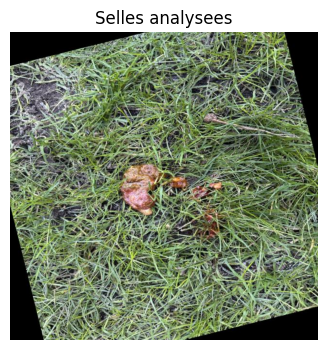


 ETAPE 1 — Prediction CNN (MobileNetV2)
 Classes detectees : ['Blood', 'Diarrhoea']
 Confiances :
   Blood           : 1.000 XXXXXXXXXXXXXXXXXXX
   Diarrhoea       : 1.000 XXXXXXXXXXXXXXXXXXX
   LackOfWater     : 0.001 
   Normal          : 0.002 
   SoftPoop        : 0.000 
   Worms           : 0.000 

 ETAPE 2 — RAG + Knowledge Base

   RAPPORT VÉTÉRINAIRE — ANALYSE DES SELLES

 Condition détectée : Sang dans les selles
 Confiance          : 100.0%
 Niveau d'urgence   : HAUTE

 Maladies probables :
   • Parvovirose
   • Hémorragie gastro-intestinale
   • Colite hémorragique
   • Intoxication

 Symptômes associés :
   • Léthargie
   • Vomissements
   • Perte d'appétit
   • Douleurs abdominales

 Traitement recommandé :
   → Consultation vétérinaire URGENTE
   → Réhydratation intraveineuse
   → Antibiotiques si infection bactérienne
   → Isoler le chien des autres animaux
   → Ne pas donner à manger pendant 24h

 Prévention :
   ✓ Vaccination antiparavovirose
   ✓ Éviter les ordures e

In [24]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import json # Added explicit import for json

def pipeline_complet(image_path, model_cnn, knowledge_base):

    print("=" * 60)
    print("   PIPELINE COMPLET — ANALYSE VETERINAIRE DES SELLES")
    print("=" * 60)

    # ── Afficher l'image ──
    try:
        img_display = mpimg.imread(image_path)
        plt.figure(figsize=(4, 4))
        plt.imshow(img_display)
        plt.axis('off')
        plt.title("Selles analysees", fontsize=12)
        plt.show()
    except:
        print("Image non affichee")

    # ── ETAPE 1 : CNN — Prédiction ──
    print("\n ETAPE 1 — Prediction CNN (MobileNetV2)")
    img       = load_image(image_path, IMG_SIZE)
    img_input = np.expand_dims(img, axis=0)
    confiances = model_cnn.predict( # Changed to model_cnn from model_mobilenet
        img_input, verbose=0
    )[0]

    classes_detectees = [
        CLASSES[i] for i, conf in enumerate(confiances)
        if conf > 0.5
    ]
    if not classes_detectees:
        classes_detectees = [CLASSES[np.argmax(confiances)]]

    print(f" Classes detectees : {classes_detectees}")
    print(" Confiances :")
    for cls, conf in zip(CLASSES, confiances):
        bar = 'X' * int(conf * 20)
        print(f"   {cls:15s} : {conf:.3f} {bar}")

    # ── ETAPE 2 : RAG + Knowledge Base ──  : generer le rapport veterinaire structuré
    print("\n ETAPE 2 — RAG + Knowledge Base")
    rag_result = rag_recommandation(confiances, confiances, knowledge_base)

    # Constructing context for LLM
    contexte_llm = f"Conditions détectées: {', '.join(rag_result['classes_detectees'])}\n"
    contexte_llm += f"Urgence globale: {rag_result['urgence_globale']}\n"
    contexte_llm += "Maladies probables:\n"
    for malady in rag_result['maladies_probables']:
        contexte_llm += f"- {malady}\n"
    contexte_llm += "Traitement recommandé:\n"
    for treatment in rag_result['traitement']:
        contexte_llm += f"- {treatment}\n"

    # ── ETAPE 3 : LLM Groq ── : generer la recommandation finale
    print("\n ETAPE 3 — LLM Groq (Llama3)")
    recommandation = "Erreur lors de la génération de la recommandation LLM." # Initialize with default error message
    try:
        recommandation = generer_recommandation_llm(
            contexte_llm # Pass the constructed string
        )
    except Exception as e:
        print(f"Erreur lors de l'appel au LLM Groq : {e}")
        recommandation = f"Une erreur est survenue lors de la génération de la recommandation par l'IA : {e}"

    print(f"\n Recommandation LLM :\n")
    print(recommandation)

    # ── JSON final ──  : structurer tous les résultats dans un format JSON clair et facilement exploitable
    json_final = {
        "classes_detectees" : rag_result['classes_detectees'],
        "urgence_globale"   : rag_result['urgence_globale'],
        "recommandation_llm": recommandation,
        "traitement_kb"     : rag_result['traitement']
    }

    print("\n JSON final :")
    print(json.dumps(json_final, ensure_ascii=False, indent=2))
    print("=" * 60)

    return json_final

# ── Test sur image Blood ──
sample_blood = df_test_split[
    df_test_split['Blood'] == 1
].iloc[0]
image_path_test = os.path.join(
    TRAIN_PATH, sample_blood['filename']
)
vrai_label = [c for c in CLASSES if sample_blood[c] == 1]
print(f"Vrai label : {vrai_label}")

result = pipeline_complet(
    image_path_test,
    model_mobilenet,
    knowledge_base
)


   TEST — Classe : Blood

   RAPPORT VÉTÉRINAIRE — ANALYSE DES SELLES

 Condition détectée : Sang dans les selles
 Confiance          : 100.0%
 Niveau d'urgence   : HAUTE

 Maladies probables :
   • Parvovirose
   • Hémorragie gastro-intestinale
   • Colite hémorragique
   • Intoxication

 Symptômes associés :
   • Léthargie
   • Vomissements
   • Perte d'appétit
   • Douleurs abdominales

 Traitement recommandé :
   → Consultation vétérinaire URGENTE
   → Réhydratation intraveineuse
   → Antibiotiques si infection bactérienne
   → Isoler le chien des autres animaux
   → Ne pas donner à manger pendant 24h

 Prévention :
   ✓ Vaccination antiparavovirose
   ✓ Éviter les ordures et déchets
   ✓ Surveillance régulière des selles

 Condition détectée : Diarrhée
 Confiance          : 100.0%
 Niveau d'urgence   : MOYENNE

 Maladies probables :
   • Gastro-entérite
   • Giardia
   • Changement alimentaire brutal
   • Stress

 Symptômes associés :
   • Selles liquides fréquentes
   • Déshydra

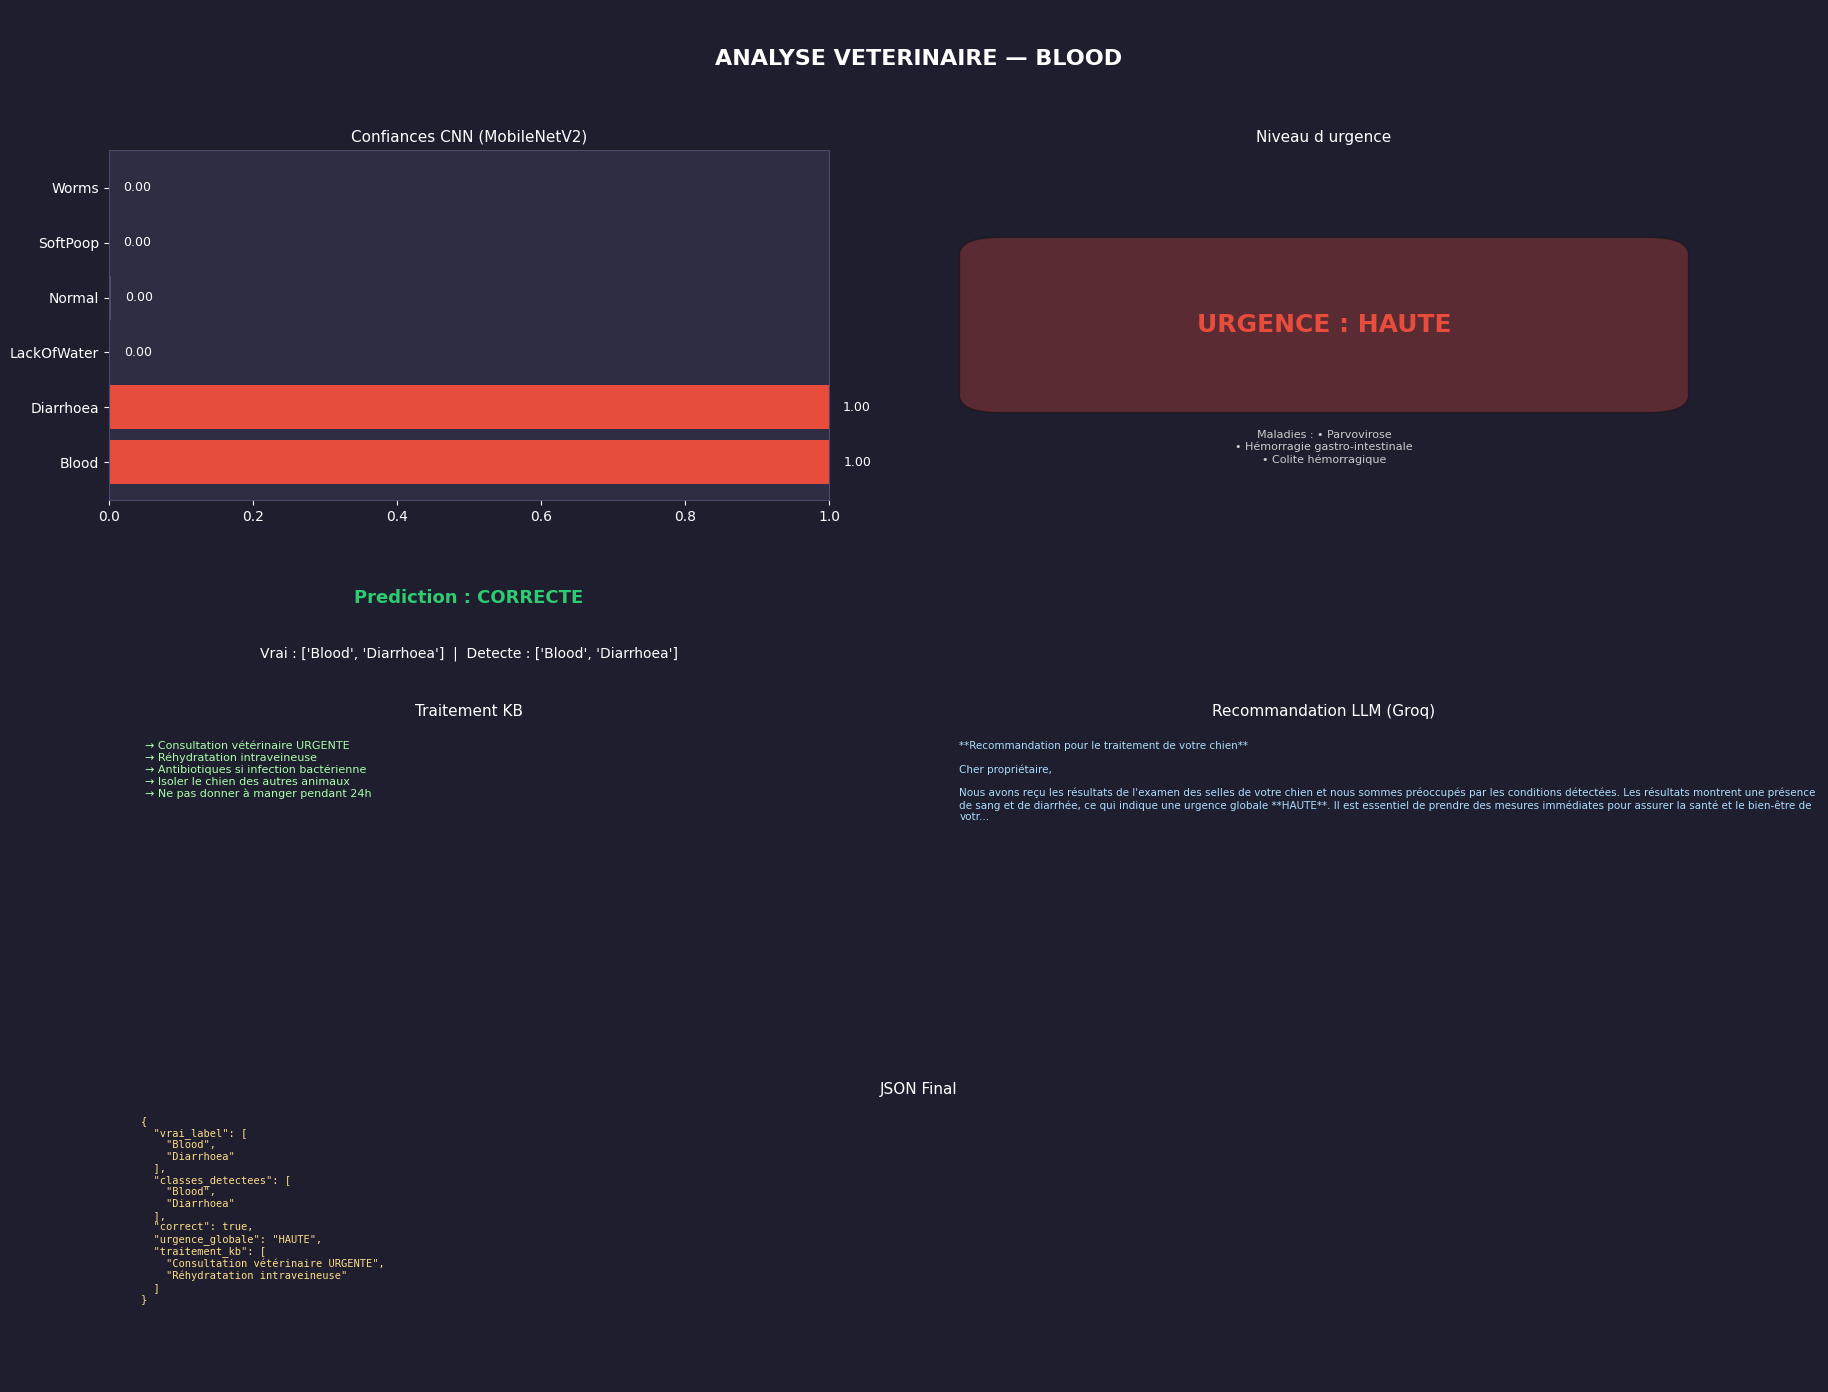

Rapport sauvegarde : rapport_Blood.png


   TEST — Classe : Diarrhoea

   RAPPORT VÉTÉRINAIRE — ANALYSE DES SELLES

 Condition détectée : Diarrhée
 Confiance          : 100.0%
 Niveau d'urgence   : MOYENNE

 Maladies probables :
   • Gastro-entérite
   • Giardia
   • Changement alimentaire brutal
   • Stress

 Symptômes associés :
   • Selles liquides fréquentes
   • Déshydratation légère
   • Ballonnements

 Traitement recommandé :
   → Diète hydrique pendant 12-24h
   → Réhydratation orale
   → Alimentation légère (riz + poulet bouilli)
   → Probiotiques
   → Consulter si persiste plus de 48h

 Prévention :
   ✓ Changements alimentaires progressifs
   ✓ Éviter les aliments humains
   ✓ Déparasitage régulier

 URGENCE GLOBALE : MOYENNE


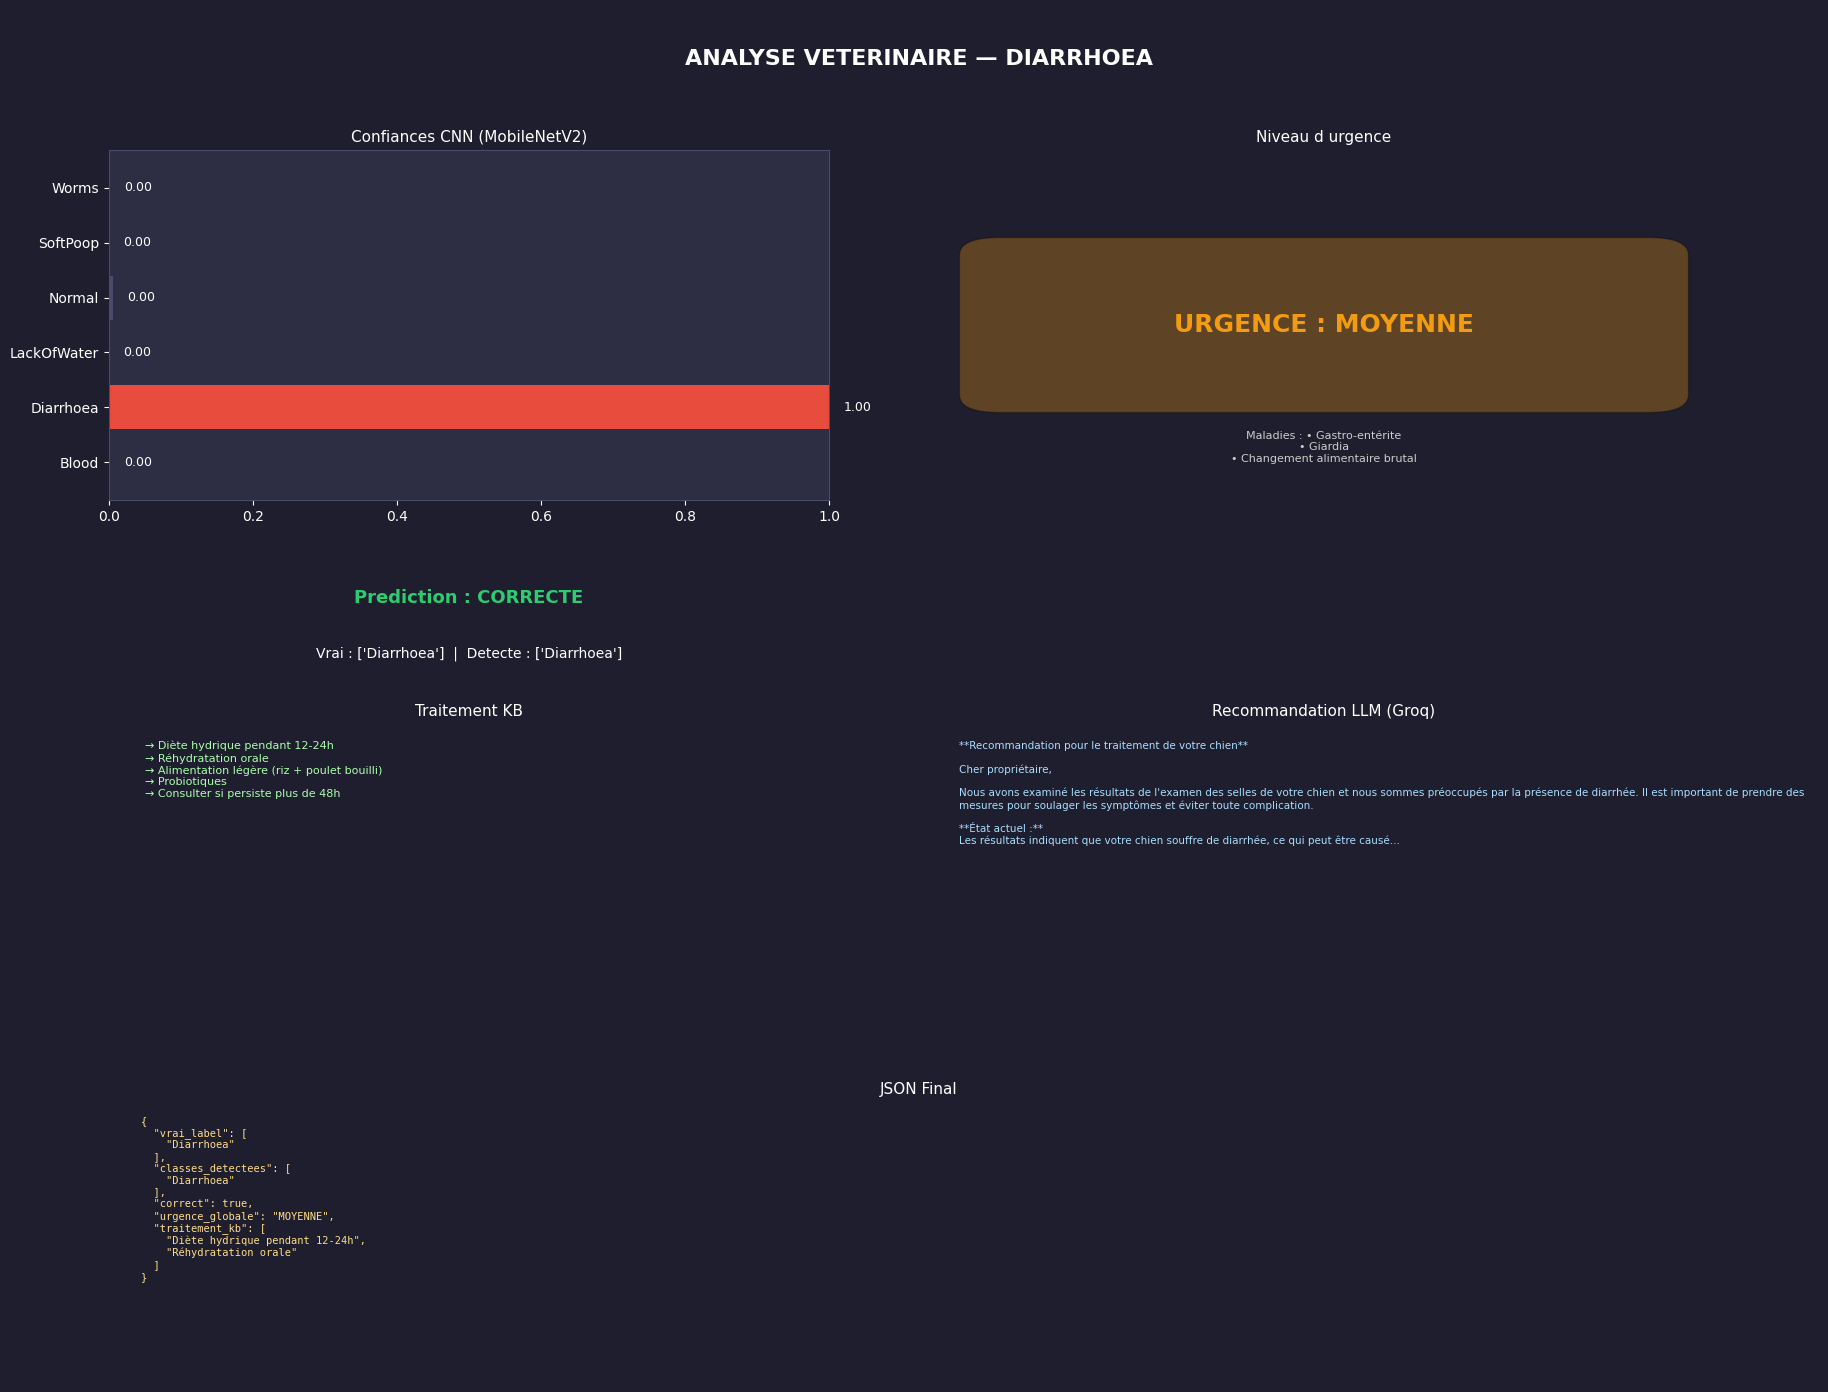

Rapport sauvegarde : rapport_Diarrhoea.png


   TEST — Classe : LackOfWater

   RAPPORT VÉTÉRINAIRE — ANALYSE DES SELLES

 Condition détectée : Déshydratation
 Confiance          : 100.0%
 Niveau d'urgence   : MOYENNE

 Maladies probables :
   • Déshydratation chronique
   • Insuffisance rénale
   • Diabète insipide

 Symptômes associés :
   • Selles très dures et sèches
   • Peau peu élastique
   • Yeux enfoncés
   • Léthargie

 Traitement recommandé :
   → Accès permanent à l'eau fraîche
   → Alimentation humide (pâtée)
   → Réhydratation orale si sévère
   → Bilan rénal si persiste

 Prévention :
   ✓ Plusieurs points d'eau disponibles
   ✓ Surveiller la consommation d'eau
   ✓ Éviter l'exposition prolongée à la chaleur

 URGENCE GLOBALE : MOYENNE


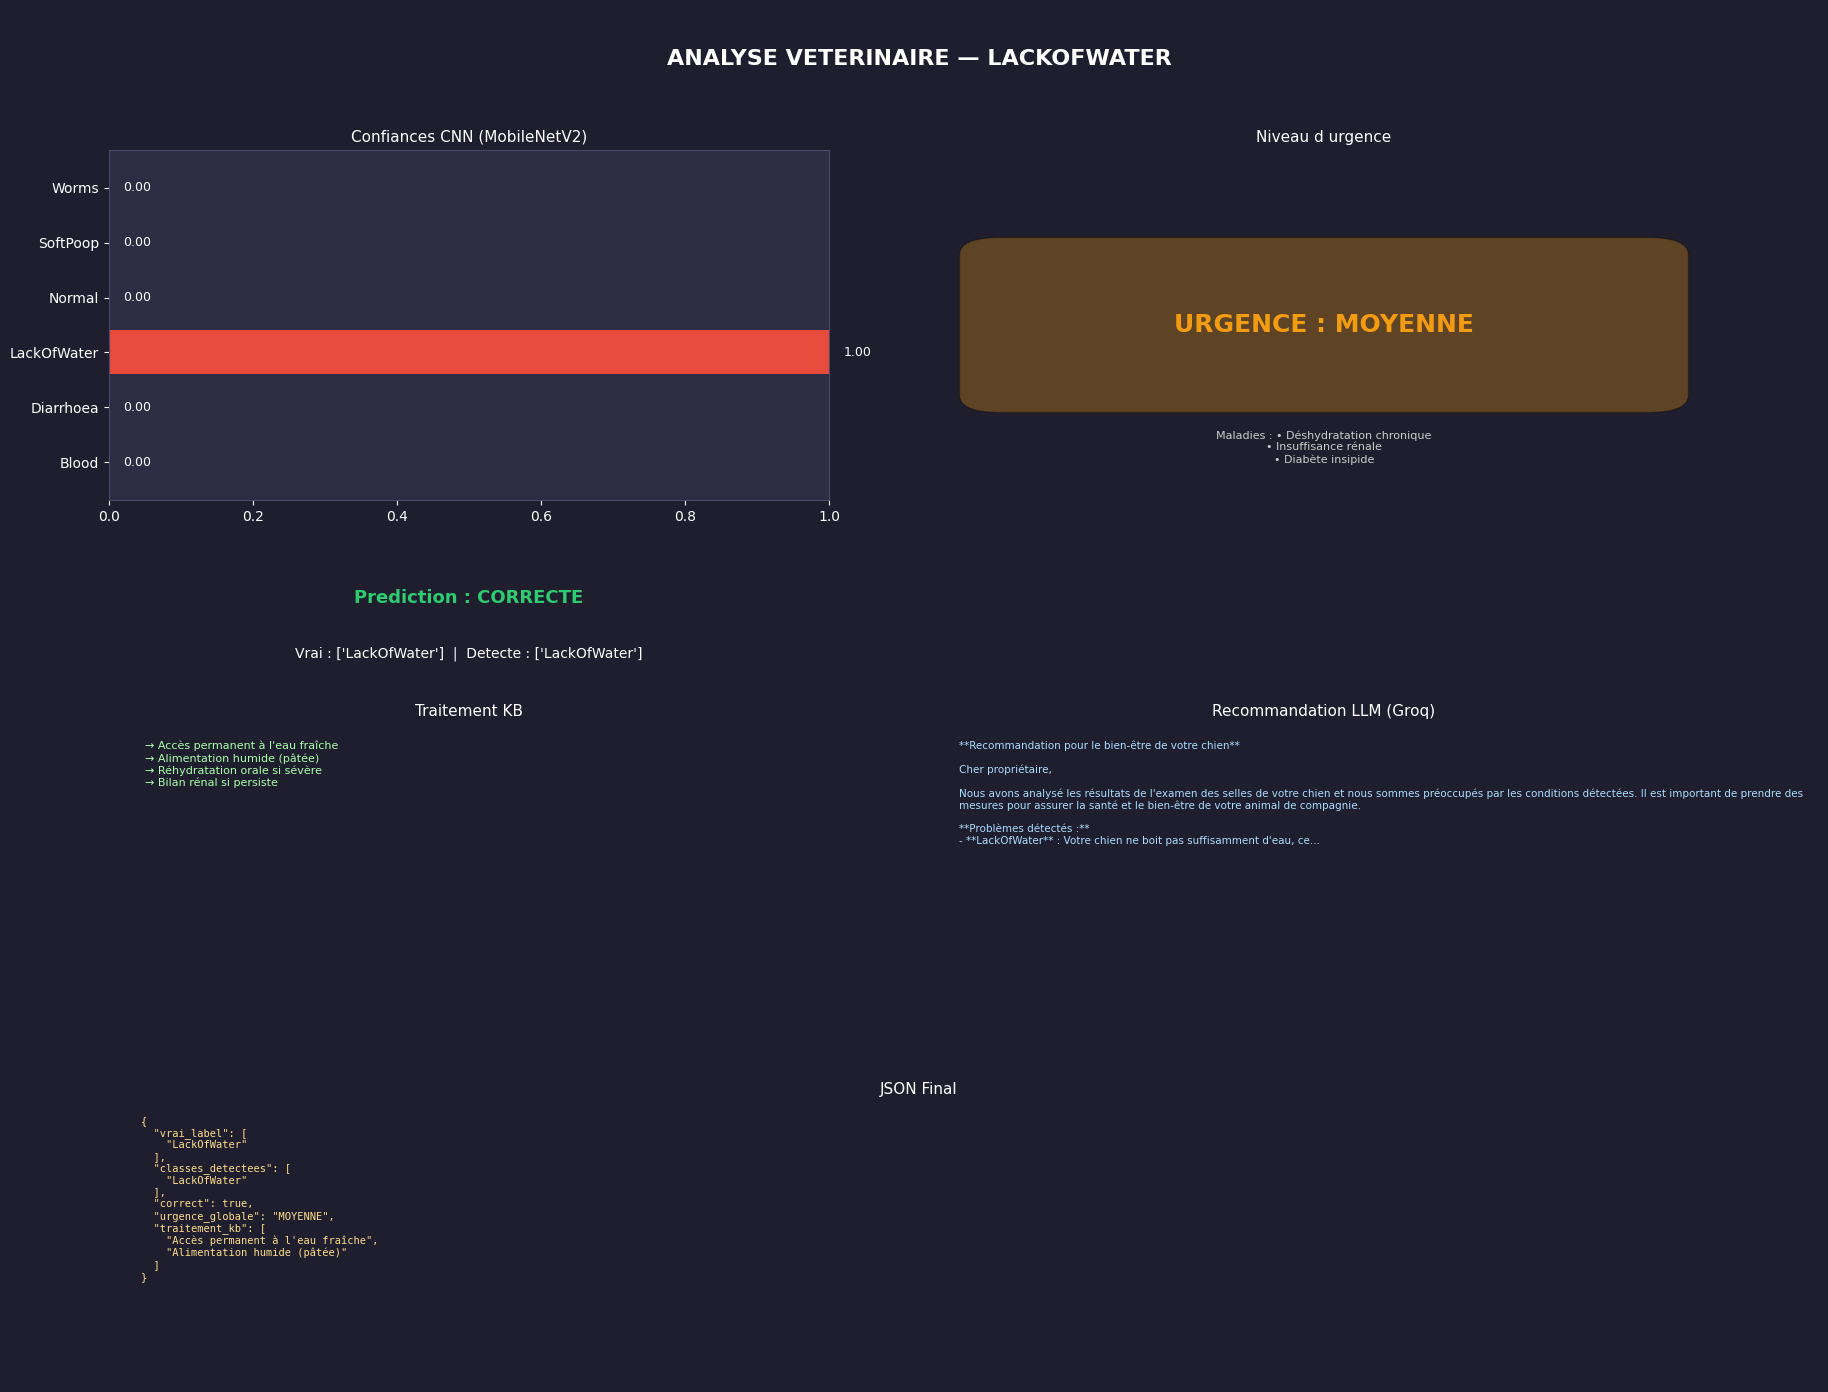

Rapport sauvegarde : rapport_LackOfWater.png


   TEST — Classe : Normal

   RAPPORT VÉTÉRINAIRE — ANALYSE DES SELLES

 Condition détectée : Selles normales
 Confiance          : 99.8%
 Niveau d'urgence   : AUCUNE

 Traitement recommandé :
   → Aucune intervention nécessaire
   → Continuer l'alimentation habituelle
   → Surveillance de routine

 Prévention :
   ✓ Alimentation équilibrée
   ✓ Exercice régulier
   ✓ Bilan vétérinaire annuel

 Condition détectée : Présence de vers
 Confiance          : 99.6%
 Niveau d'urgence   : MOYENNE

 Maladies probables :
   • Téniasis (vers plats)
   • Ascaridose (vers ronds)
   • Ankylostomose
   • Dipylidiose

 Symptômes associés :
   • Vers visibles dans les selles
   • Perte de poids
   • Ventre gonflé
   • Frottement du postérieur

 Traitement recommandé :
   → Antiparasitaire oral (Fenbendazole / Praziquantel)
   → Traitement de tous les animaux du foyer
   → Nettoyage et désinfection de l'environnement
   → Consulter le vétérinaire pour le bo

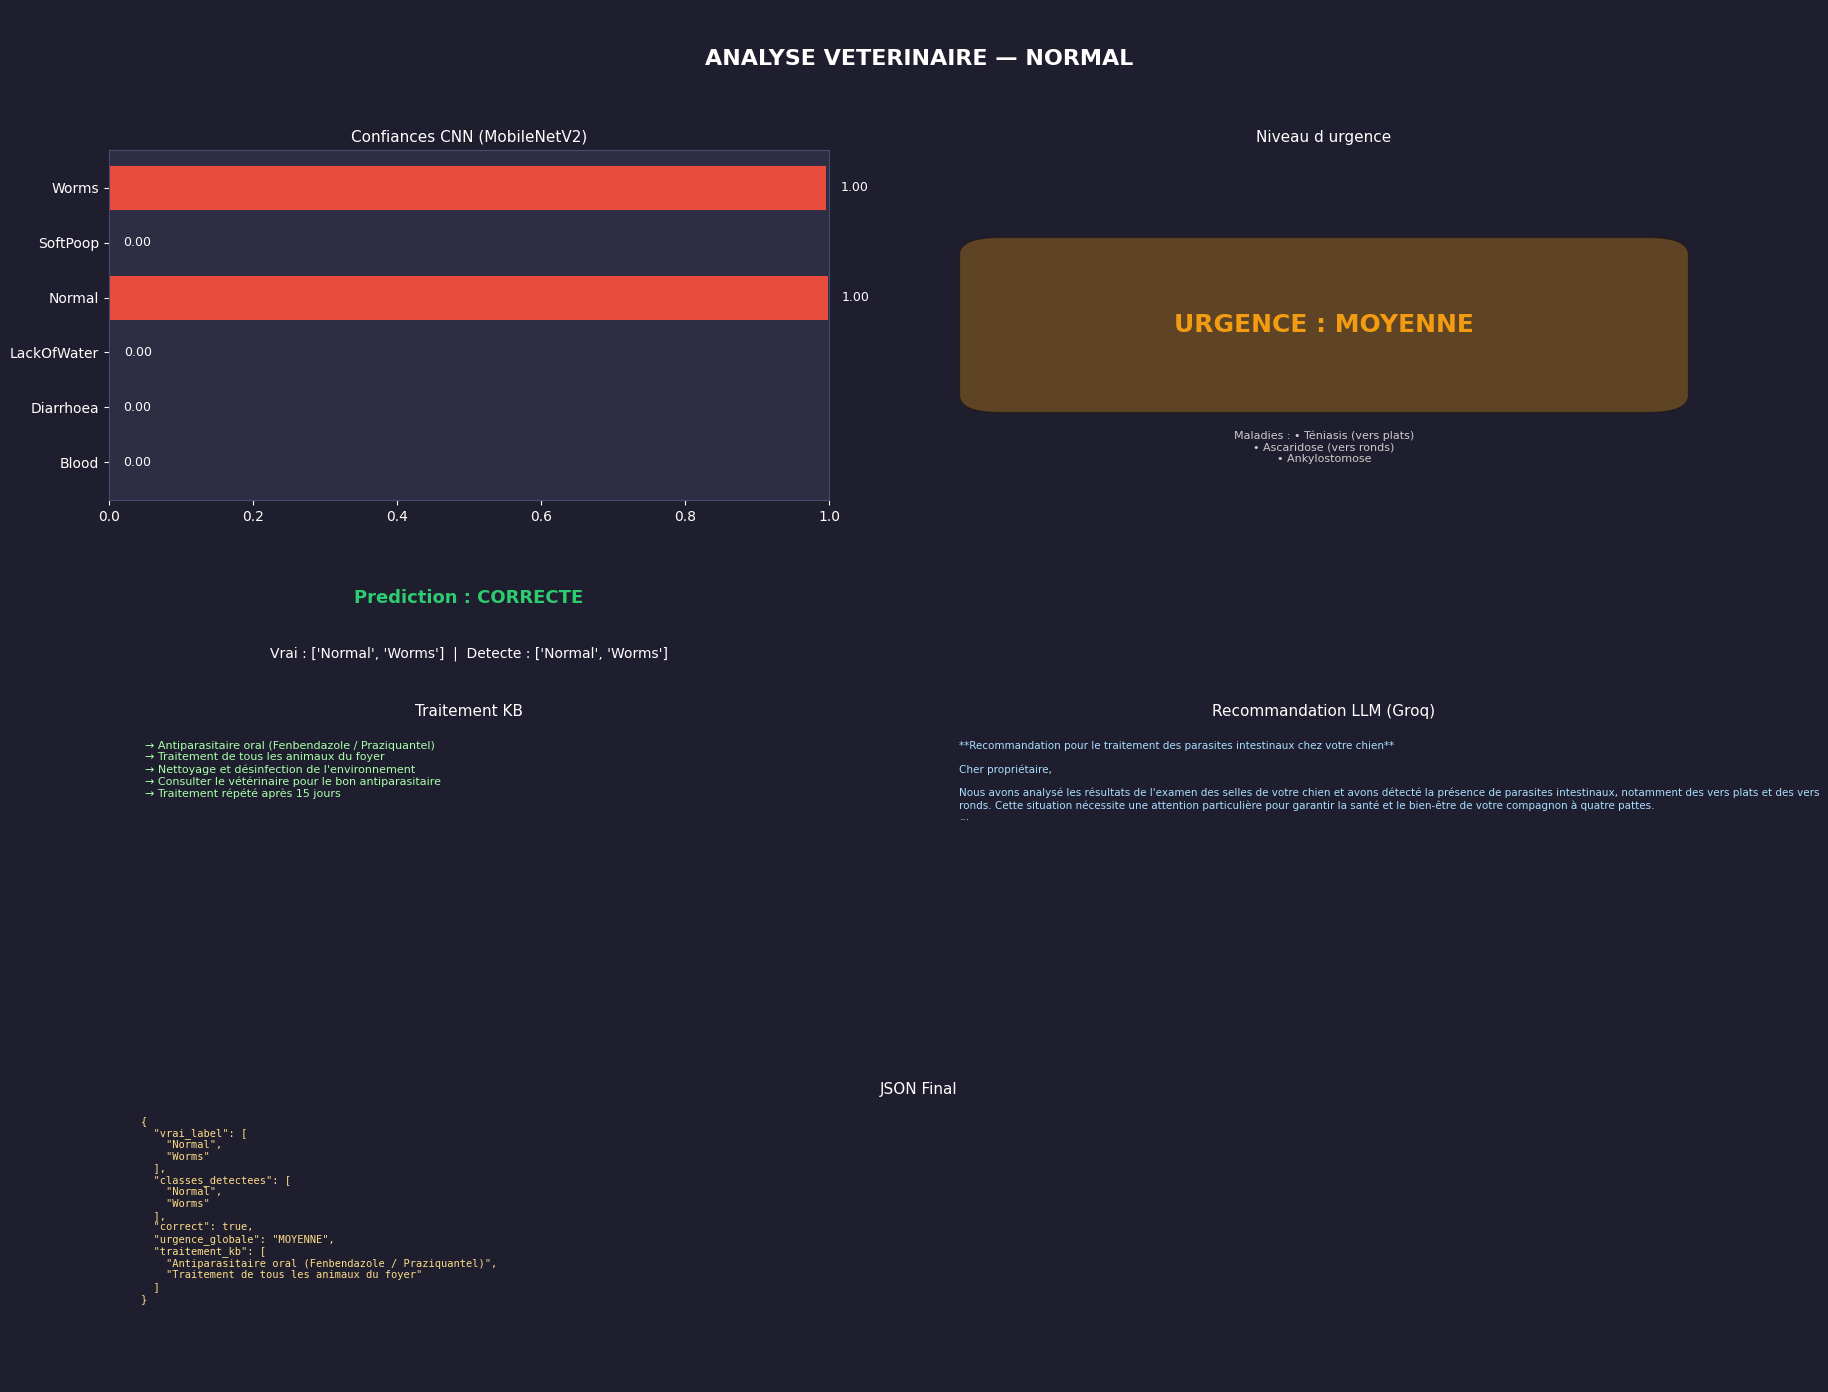

Rapport sauvegarde : rapport_Normal.png


   TEST — Classe : SoftPoop

   RAPPORT VÉTÉRINAIRE — ANALYSE DES SELLES

 Condition détectée : Selles molles
 Confiance          : 58.0%
 Niveau d'urgence   : FAIBLE

 Maladies probables :
   • Alimentation inadaptée
   • Intolérance alimentaire
   • Stress léger
   • Début de gastro-entérite

 Symptômes associés :
   • Selles peu formées
   • Légère flatulence
   • Appétit conservé

 Traitement recommandé :
   → Réduire les friandises et extras
   → Alimentation simple et digestible
   → Probiotiques
   → Surveiller l'évolution 48h

 Prévention :
   ✓ Alimentation régulière et adaptée
   ✓ Éviter les changements brusques
   ✓ Pas de restes de table

 URGENCE GLOBALE : FAIBLE


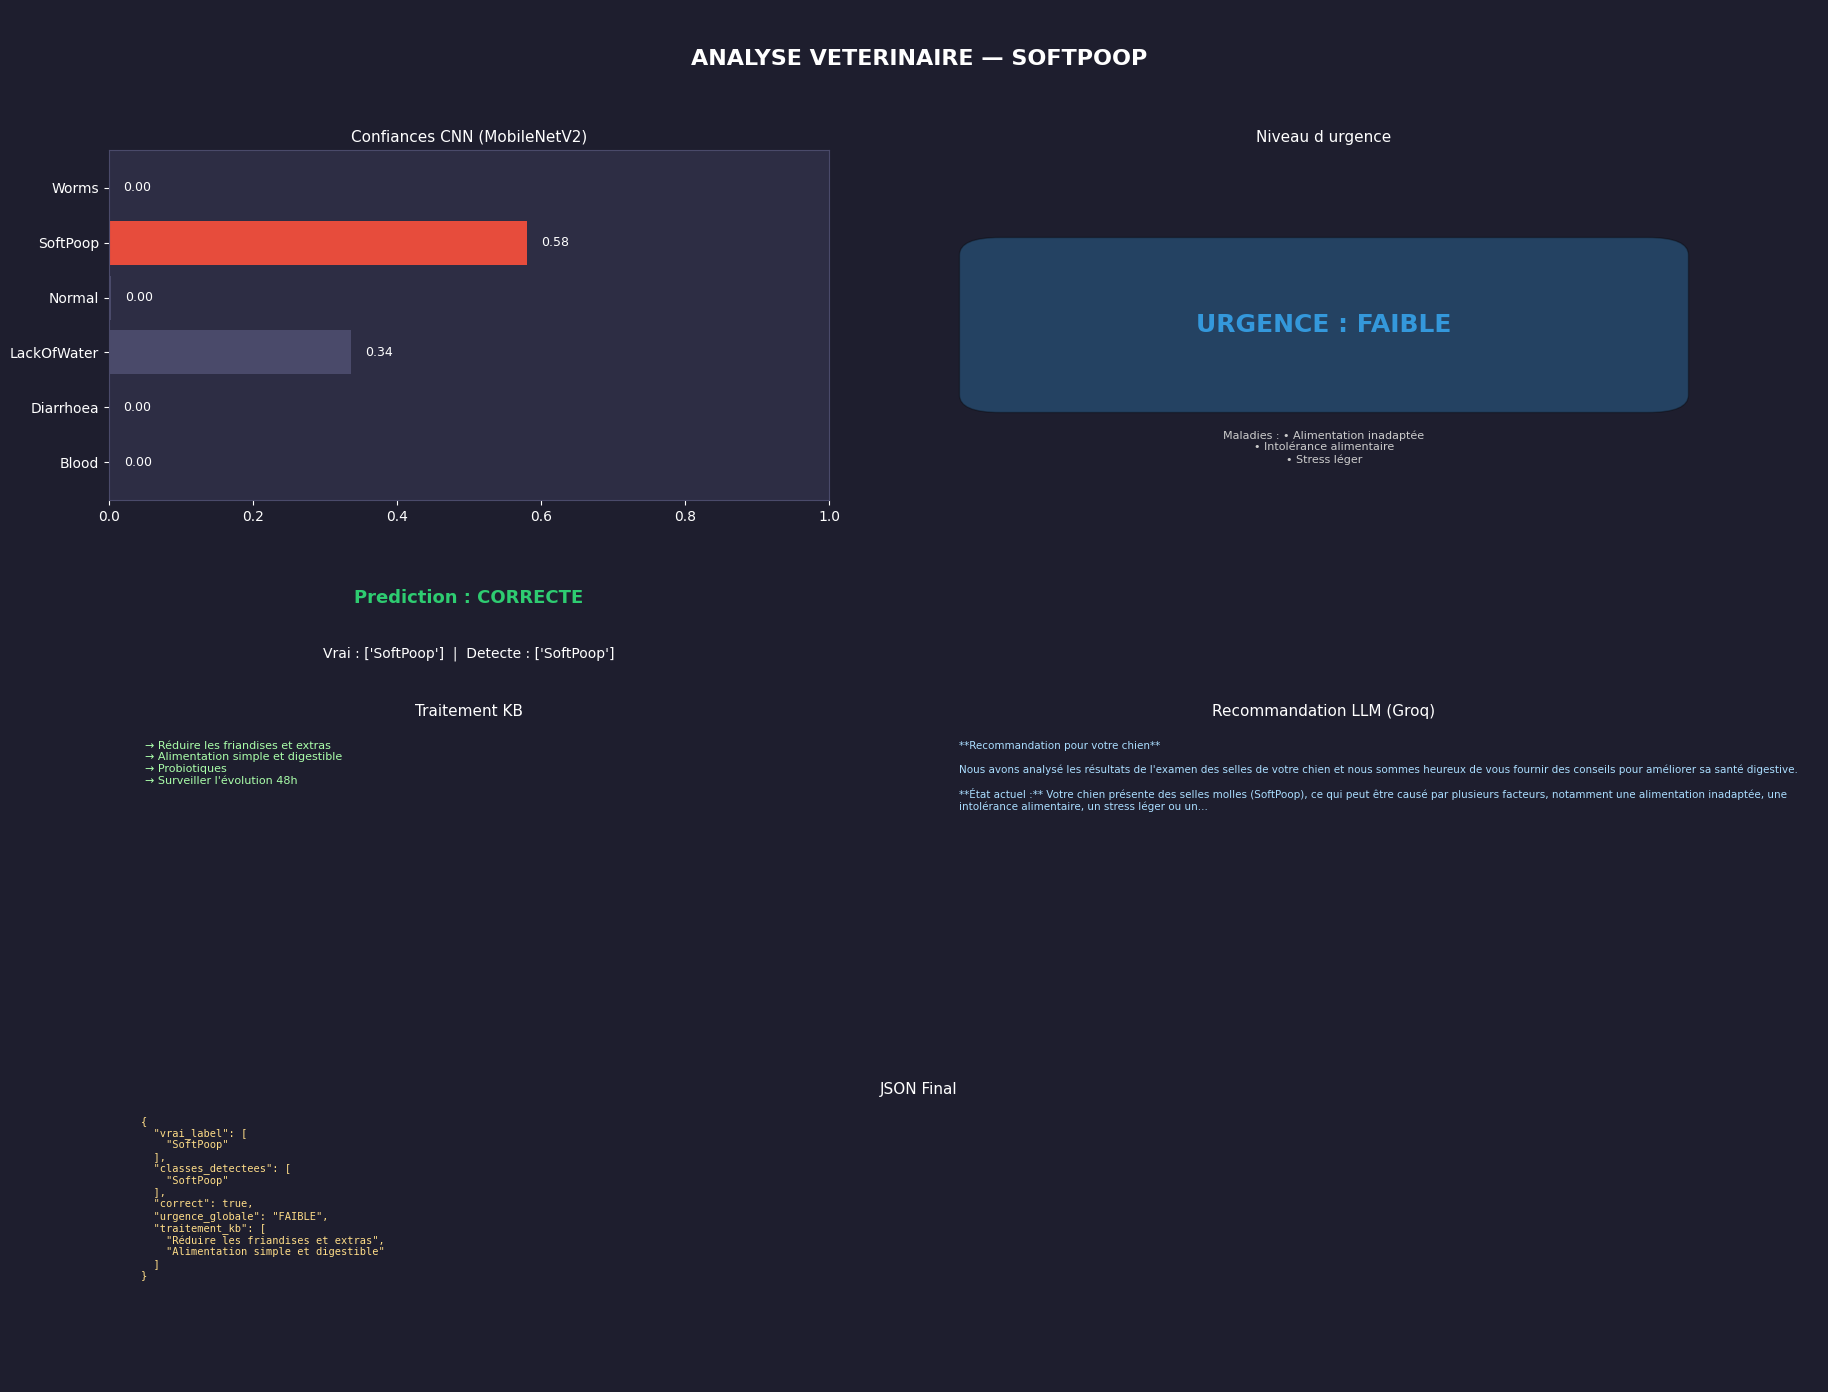

Rapport sauvegarde : rapport_SoftPoop.png


   TEST — Classe : Worms

   RAPPORT VÉTÉRINAIRE — ANALYSE DES SELLES

 Condition détectée : Selles normales
 Confiance          : 99.8%
 Niveau d'urgence   : AUCUNE

 Traitement recommandé :
   → Aucune intervention nécessaire
   → Continuer l'alimentation habituelle
   → Surveillance de routine

 Prévention :
   ✓ Alimentation équilibrée
   ✓ Exercice régulier
   ✓ Bilan vétérinaire annuel

 Condition détectée : Présence de vers
 Confiance          : 99.6%
 Niveau d'urgence   : MOYENNE

 Maladies probables :
   • Téniasis (vers plats)
   • Ascaridose (vers ronds)
   • Ankylostomose
   • Dipylidiose

 Symptômes associés :
   • Vers visibles dans les selles
   • Perte de poids
   • Ventre gonflé
   • Frottement du postérieur

 Traitement recommandé :
   → Antiparasitaire oral (Fenbendazole / Praziquantel)
   → Traitement de tous les animaux du foyer
   → Nettoyage et désinfection de l'environnement
   → Consulter le vétérinaire pour le bon an

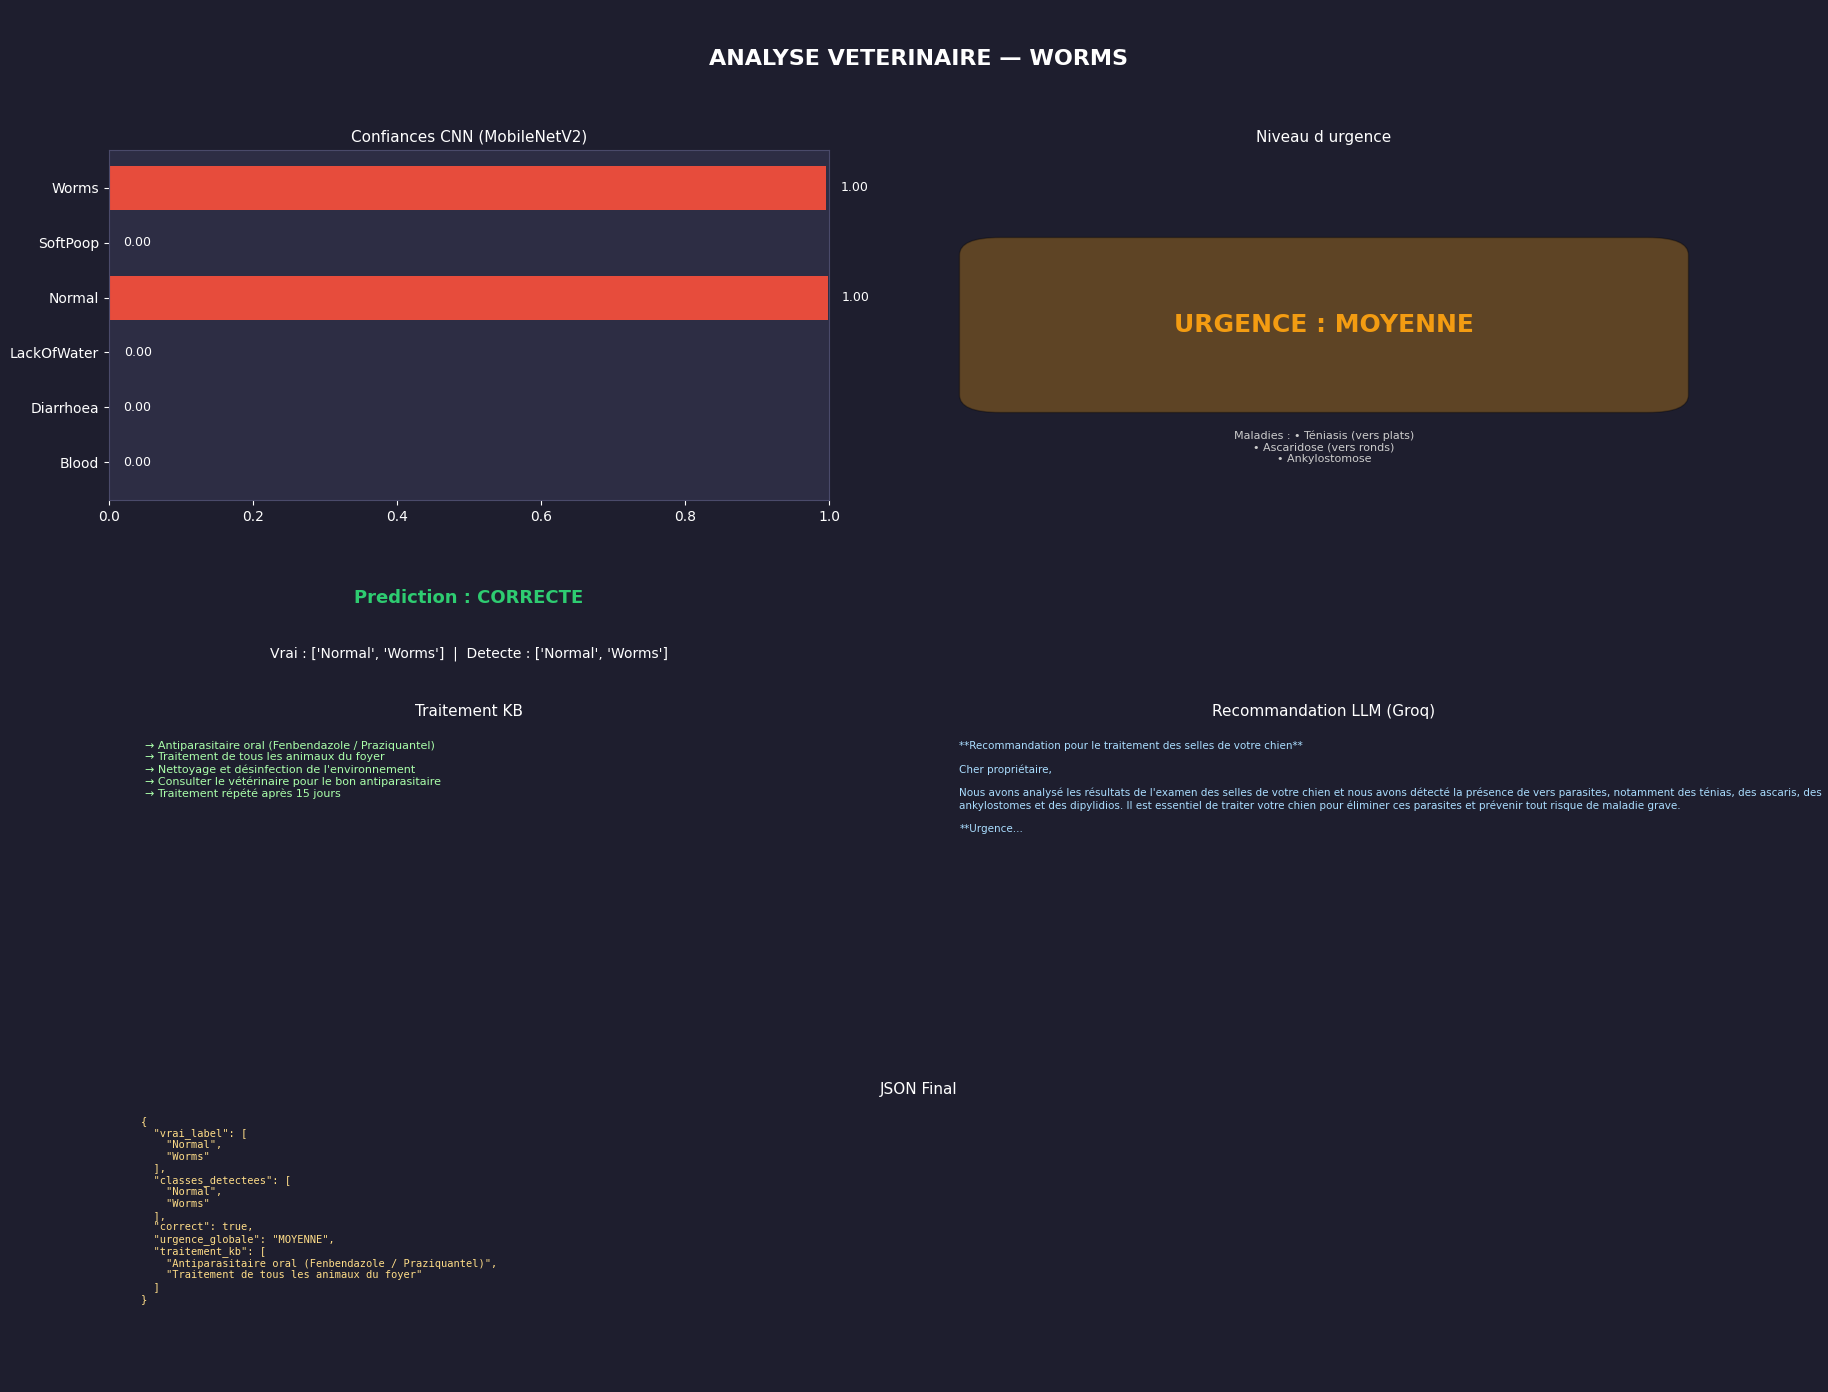

Rapport sauvegarde : rapport_Worms.png



In [25]:
# ════════════════════════════════════════════
# 13. TEST SUR TOUTES LES CLASSES
# ════════════════════════════════════════════

import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches

for cls_test in CLASSES:
    print("\n" + "=" * 60)
    print(f"   TEST — Classe : {cls_test}")
    print("=" * 60)

    # ── Sélectionner une image ──
    sample = df_test_split[df_test_split[cls_test] == 1]
    if len(sample) == 0:
        print(f"Aucune image de classe {cls_test}")
        continue

    row   = sample.iloc[0]
    fpath = os.path.join(TRAIN_PATH, row['filename'])

    # ── Vrai label ──
    vrai_label = [c for c in CLASSES if row[c] == 1]

    # ── Prédiction CNN ──
    img        = load_image(fpath, IMG_SIZE)
    img_input  = np.expand_dims(img, axis=0)
    confiances = model_mobilenet.predict(img_input, verbose=0)[0]

    classes_detectees = [
        CLASSES[i] for i, conf in enumerate(confiances)
        if conf > 0.5
    ]
    if not classes_detectees:
        classes_detectees = [CLASSES[np.argmax(confiances)]]

    correct = set(vrai_label) == set(classes_detectees)

    # ── RAG ──
    rag_result = rag_recommandation(confiances, confiances, knowledge_base)

    # Constructing context for LLM
    contexte_llm = f"Conditions détectées: {', '.join(rag_result['classes_detectees'])}\n"
    contexte_llm += f"Urgence globale: {rag_result['urgence_globale']}\n"
    contexte_llm += "Maladies probables:\n"
    for malady in rag_result['maladies_probables']:
        contexte_llm += f"- {malady}\n"
    contexte_llm += "Traitement recommandé:\n"
    for treatment in rag_result['traitement']:
        contexte_llm += f"- {treatment}\n"

    # ── LLM ──
    recommandation = generer_recommandation_llm(
        contexte_llm
    )

    # ════════════════════════════════════════
    # VISUALISATION COMPLETE
    # ════════════════════════════════════════
    fig = plt.figure(figsize=(18, 14))
    fig.patch.set_facecolor('#1e1e2e')

    # ── Panel 1 : Titre ──
    ax_title = fig.add_axes([0, 0.93, 1, 0.07])
    ax_title.set_facecolor('#2d2d44')
    ax_title.text(0.5, 0.5,
        f"ANALYSE VETERINAIRE — {cls_test.upper()}",
        ha='center', va='center',
        fontsize=16, fontweight='bold', color='white')
    ax_title.axis('off')

    # ── Panel 2 : Confiances CNN ──
    ax_bar = fig.add_axes([0.05, 0.65, 0.40, 0.25])
    ax_bar.set_facecolor('#2d2d44')
    colors_bar = [
        '#e74c3c' if c in classes_detectees else '#4a4a6a'
        for c in CLASSES
    ]
    bars = ax_bar.barh(CLASSES, confiances, color=colors_bar)
    ax_bar.set_xlim(0, 1)
    ax_bar.set_title('Confiances CNN (MobileNetV2)',
                     color='white', fontsize=11)
    ax_bar.tick_params(colors='white')
    ax_bar.set_facecolor('#2d2d44')
    for spine in ax_bar.spines.values():
        spine.set_edgecolor('#4a4a6a')
    for bar, conf in zip(bars, confiances):
        ax_bar.text(conf + 0.02, bar.get_y() + bar.get_height()/2,
                   f'{conf:.2f}', va='center',
                   color='white', fontsize=9)

    # ── Panel 3 : Statut prédiction ──
    ax_status = fig.add_axes([0.05, 0.52, 0.40, 0.10])
    ax_status.set_facecolor('#2d2d44')
    color_status = '#2ecc71' if correct else '#e74c3c'
    status_text  = 'CORRECTE' if correct else 'INCORRECTE'
    ax_status.text(0.5, 0.6,
        f"Prediction : {status_text}",
        ha='center', va='center',
        fontsize=13, fontweight='bold',
        color=color_status)
    ax_status.text(0.5, 0.2,
        f"Vrai : {vrai_label}  |  Detecte : {classes_detectees}",
        ha='center', va='center',
        fontsize=10, color='white')
    ax_status.axis('off')

    # ── Panel 4 : Urgence ──
    ax_urgence = fig.add_axes([0.50, 0.65, 0.45, 0.25])
    ax_urgence.set_facecolor('#2d2d44')
    urgence     = rag_result['urgence_globale']
    color_urgence = {
        'HAUTE'  : '#e74c3c',
        'MOYENNE': '#f39c12',
        'FAIBLE' : '#3498db',
        'AUCUNE' : '#2ecc71'
    }.get(urgence, 'white')

    ax_urgence.add_patch(mpatches.FancyBboxPatch(
        (0.1, 0.3), 0.8, 0.4,
        boxstyle="round,pad=0.05",
        facecolor=color_urgence, alpha=0.3
    ))
    ax_urgence.text(0.5, 0.5,
        f"URGENCE : {urgence}",
        ha='center', va='center',
        fontsize=18, fontweight='bold',
        color=color_urgence)

    maladies = rag_result['maladies_probables']
    if maladies:
        maladies_text = '\n'.join(
            [f"• {m}" for m in maladies[:3]]
        )
        ax_urgence.text(0.5, 0.15,
            f"Maladies : {maladies_text}",
            ha='center', va='center',
            fontsize=8, color='#cccccc')
    ax_urgence.axis('off')
    ax_urgence.set_title('Niveau d urgence',
                         color='white', fontsize=11)

    # ── Panel 5 : Traitement KB ──
    ax_trait = fig.add_axes([0.05, 0.25, 0.40, 0.24])
    ax_trait.set_facecolor('#2d2d44')
    ax_trait.set_title('Traitement KB',
                        color='white', fontsize=11)
    traitements = rag_result['traitement']
    trait_text  = '\n'.join(
        [f"→ {t}" for t in traitements]
    )
    ax_trait.text(0.05, 0.95, trait_text,
        ha='left', va='top',
        fontsize=8, color='#aaffaa',
        transform=ax_trait.transAxes,
        wrap=True)
    ax_trait.axis('off')

    # ── Panel 6 : Recommandation LLM ──
    ax_llm = fig.add_axes([0.50, 0.25, 0.45, 0.24])
    ax_llm.set_facecolor('#2d2d44')
    ax_llm.set_title('Recommandation LLM (Groq)',
                      color='white', fontsize=11)
    llm_short = recommandation[:400] + '...' \
        if len(recommandation) > 400 else recommandation
    ax_llm.text(0.05, 0.95, llm_short,
        ha='left', va='top',
        fontsize=7.5, color='#aaddff',
        transform=ax_llm.transAxes,
        wrap=True)
    ax_llm.axis('off')

    # ── Panel 7 : JSON ──
    ax_json = fig.add_axes([0.05, 0.02, 0.90, 0.20])
    ax_json.set_facecolor('#1a1a2e')
    ax_json.set_title('JSON Final',
                       color='white', fontsize=11)
    json_final = {
        "vrai_label"        : vrai_label,
        "classes_detectees" : classes_detectees,
        "correct"           : correct,
        "urgence_globale"   : urgence,
        "traitement_kb"     : traitements[:2]
    }
    json_text = json.dumps(
        json_final, ensure_ascii=False, indent=2
    )
    ax_json.text(0.02, 0.95, json_text,
        ha='left', va='top',
        fontsize=7.5, color='#ffdd88',
        transform=ax_json.transAxes,
        fontfamily='monospace')
    ax_json.axis('off')

    plt.savefig(
        f'rapport_{cls_test}.png',
        dpi=150, bbox_inches='tight',
        facecolor='#1e1e2e'
    )
    plt.show()
    print(f"Rapport sauvegarde : rapport_{cls_test}.png\n")


In [ ]:
# Sauvegarder le modèle MobileNetV2 en format SavedModel (recommandé)
model_mobilenet.save('model_mobilenet_selles.keras')

# OU en TFLite pour une app mobile/web légère
converter = tf.lite.TFLiteConverter.from_keras_model(model_mobilenet)
tflite_model = converter.convert()
with open('model_mobilenet_selles.tflite', 'wb') as f:
    f.write(tflite_model)

print("Modèle exporté !")